<a href="https://colab.research.google.com/github/pedrof0rtes/eeg-psychosis/blob/main/EEG_Psychosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Datasets:**

*EEG: First Episode Psychosis vs. Control Resting Task 1*: https://openneuro.org/datasets/ds003944/versions/1.0.1

*EEG: First Episode Psychosis vs. Control Resting Task 2*: https://openneuro.org/datasets/ds003947/versions/1.0.1


# **Introduction**

Psychosis is a mental state characterized by a break with reality and commonly manifests through delusions, hallucinations, and disorganization of thought and speech.

The **first-episode psychosis (FEP)** marks the first occurrence of this state in an individual's life, corresponding to the acute phase of psychosis. The individual in FEP will often progress to a diagnosis of schizophrenia or bipolar disorder, but this outcome is heterogeneous.

It is known that the longer the duration of untreated psychosis, the **worse the prognosis of the case**. For this reason, early identification of this condition while still in its initial stages is imperative.

**Based on electroencephalogram (EEG) data from a public dataset, this project aims to implement classification models based on machine learning algorithms with the objective of:**

**1) <font color=#4682b4>Assisting in the identification of FEP.</font>**

**2) <font color=#4682b4>Identifying EEG characteristics with the greatest importance for FEP detection.</font>**

<br>

<br>


---


# **Method**

* In order to improve the differentiation between subjects with FEP and healthy subjects, supporting diagnostic decision-making, different machine learning algorithms will be implemented to train **classification models**.

* The input data for these models originate from electroencephalogram (EEG) sensors, stored in binary format. First and foremost, these raw data will go through multiple preprocessing stages until they become a **feature dataframe**.

* This feature dataframe will be the input for the models. Due to the high dimensionality of this dataframe, since each feature will be extracted for dozens of EEG channels, it will be essential to **select the most important features and discard the rest.**

* Each step of this project, as it involves processing times that are not very fast, includes a **time estimate at the beginning of the cell. This may vary due to Google Colab fluctuations.**

* **The feature extraction procedure adopted, including entropy attributes, statistical metrics, and signal frequency features, was based on the work of *Gengeç Benli (2023).***

<br>

**Dataset**

The datasets used in this project are publicly available through OpenNeuro at the following links:

https://openneuro.org/datasets/ds003944/versions/1.0.1

https://openneuro.org/datasets/ds003947/versions/1.0.1
<br>

These datasets consist of EEG data collected from **healthy individuals (n=62) and individuals with FEP (n=81)**, at rest, for 5 minutes. The data were stored in BrainVision format, which includes a .eeg file (binary EEG signal data) and other metadata files.

<br>



---


# **Commented code**



### <font color=#4682b4>**Part 1 - Setup**</font>

#### **Initial setup**

<font color=#BA1B15>[This step is mandatory. If you wish, after completing the "initial setup" skip the dataset download and the entire Part 2, and go straight to Part 3 (EDA)]</font>

* Import necessary libraries.

* Identify subjects in the sample.

* Define psychosis and control groups to group subjects.

In [ ]:
# Install missing libraries in the Colab environment
# Estimated processing time: ~30 seconds
# Restart the environment after installation, if necessary

!pip install boto3 pyprep mne_icalabel autoreject --quiet

In [ ]:
# Preparing the libraries
# Estimated time: ~20 seconds

# Dataset download
import os
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import urllib.request

# EEG preprocessing
import mne
from mne.preprocessing import ICA
from mne_icalabel import label_components
from pyprep.find_noisy_channels import NoisyChannels
from autoreject import get_rejection_threshold
from statsmodels.tsa.ar_model import AutoReg

# Pandas, numpy, regex and visualization
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# SciPy
from scipy import stats
from scipy.signal import welch
from scipy.stats import levene
from scipy.stats import normaltest

# Scikit-Learn
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, make_scorer
from sklearn.base import clone

In [ ]:
# boto3 import settings
S3 = boto3.client('s3', config=Config(signature_version=UNSIGNED), region_name='us-east-1')
BUCKET = 'openneuro.org'

# Setting the Colab directory
output_dir = "/content/EEG_Datasets"

# Defining subjects to import from datasets
psychosis_set_1 = [
    'sub-1824', 'sub-1983', 'sub-1990', 'sub-1998', 'sub-2000', 'sub-2002',
    'sub-2015', 'sub-2018', 'sub-2020', 'sub-2028', 'sub-2034', 'sub-2041',
    'sub-2054', 'sub-2067', 'sub-2070', 'sub-2072', 'sub-2081', 'sub-2086',
    'sub-2089', 'sub-2092', 'sub-2093', 'sub-2095', 'sub-2105', 'sub-2109',
    'sub-2117', 'sub-2125', 'sub-2131', 'sub-2133', 'sub-2134', 'sub-2135',
    'sub-2138', 'sub-2141', 'sub-2143', 'sub-2149', 'sub-2171', 'sub-2174',
    'sub-2176', 'sub-2177', 'sub-2178', 'sub-2179', 'sub-2187', 'sub-2195',
    'sub-2197', 'sub-2218', 'sub-2170A', 'sub-2174A', 'sub-2176A', 'sub-2177A',
    'sub-2184A', 'sub-2217A'
]

control_set_1 = [
    'sub-1448', 'sub-1971', 'sub-1989', 'sub-1999', 'sub-2009', 'sub-2017',
    'sub-2025', 'sub-2038', 'sub-2044', 'sub-2071', 'sub-2073', 'sub-2082',
    'sub-2096', 'sub-2110', 'sub-2122', 'sub-2124', 'sub-2128', 'sub-2129',
    'sub-2136', 'sub-2137', 'sub-2142', 'sub-2193', 'sub-2196', 'sub-2199',
    'sub-2213', 'sub-2221', 'sub-2222', 'sub-2223', 'sub-2140A', 'sub-2193A',
    'sub-2214A', 'sub-2221A'
]

# Full Dataset 1
dataset_1 = psychosis_set_1 + control_set_1

# Defining subjects to import from datasets
psychosis_set_2 = [
    'sub-2237A', 'sub-2245A', 'sub-2246A', 'sub-2249A', 'sub-2252A',
    'sub-2266A', 'sub-2276A', 'sub-2279A', 'sub-2318A', 'sub-2336A',
    'sub-2351A', 'sub-2367A', 'sub-2379A', 'sub-2392A', 'sub-2397A',
    'sub-2403A', 'sub-2418A', 'sub-2419A', 'sub-2431A', 'sub-2448A',
    'sub-2476A', 'sub-2477A', 'sub-2480A', 'sub-2498A', 'sub-2503A',
    'sub-2505A', 'sub-2514A', 'sub-2526A', 'sub-2530A', 'sub-2578A',
    'sub-2581A'
]

control_set_2 = [
    'sub-2235A', 'sub-2238A', 'sub-2240A', 'sub-2259A', 'sub-2262A',
    'sub-2267A', 'sub-2268A', 'sub-2269A', 'sub-2290A', 'sub-2320A',
    'sub-2342A', 'sub-2350A', 'sub-2355A', 'sub-2356A', 'sub-2372A',
    'sub-2384A', 'sub-2387A', 'sub-2389A', 'sub-2406A', 'sub-2426A',
    'sub-2430A', 'sub-2442A', 'sub-2456A', 'sub-2479A', 'sub-2494A',
    'sub-2496A', 'sub-2512A', 'sub-2518A', 'sub-2538A', 'sub-2574A'
]

# Full Dataset 2
dataset_2 = psychosis_set_2 + control_set_2

# Total dataset
dataset_all = dataset_1 + dataset_2

In [ ]:
# Summary of data used in the model
print("\nDownload @ OpenNeuro\n")
print(f"  Dataset 1 → {len(psychosis_set_1)} psychosis + {len(control_set_1)} control = {len(dataset_1)} subjects")
print(f"  Dataset 2 → {len(psychosis_set_2)} psychosis + {len(control_set_2)} control = {len(dataset_2)} subjects")

print(f"  Total dataset → {len(psychosis_set_1)+len(psychosis_set_2)} psychosis + {len(control_set_1)+len(control_set_2)} control = {len(dataset_all)} subjects")
print(f"  Estimated size → ~{len(dataset_all)*100} MB\n")

In [ ]:
# Defining a dictionary for the subjects
SUBJECTS = {}

for s in psychosis_set_1:
    SUBJECTS[s] = ("ds003944", "Psychosis", "Rest")
for s in control_set_1:
    SUBJECTS[s] = ("ds003944", "Control", "Rest")

for s in psychosis_set_2:
    SUBJECTS[s] = ("ds003947", "Psychosis", "rest")
for s in control_set_2:
    SUBJECTS[s] = ("ds003947", "Control", "rest")

print(SUBJECTS)

<br>

#### **Download raw datasets**

The script below allows for the selective download of specific subjects from the sample. For the purposes of this project, we will use all subjects.

These datasets do not contain Markerfile (.vmrk) files, which are required for later preprocessing steps. **Therefore, it will be necessary to generate an empty .vmrk file and add a "MarkerFile" string to the metadata file (.vhdr) of the datasets.**
<br><br>


* Download each subject from the OpenNeuro dataset.

* Check for directory existence.

* Define correction functions for missing files in the datasets.

* Define import and initial cleaning function for the data:
  1) Standardization of channel names - *for example: "FP1" : Fp1"*.
  2) Define auxiliary channel types (EOG, ECG, Misc).
  3) Remove M2 (reference) and Misc channels.
  4) Resample the signal to 250Hz.
<br>

In [ ]:
# Downloading the datasets
# Estimated time: ~4 minutes

# Define a function to download specific subjects from the global dataset
EEG_FILES = [
    "_task-{task}_eeg.eeg",
    "_task-{task}_eeg.vhdr",
    "_task-{task}_channels.tsv",
    "_task-{task}_eeg.json",
]

def download_subject_s3(subject_id, max_retries=3):
    import time
    dataset, group, task = SUBJECTS[subject_id]
    eeg_dir = os.path.join(output_dir, dataset, subject_id, "eeg")
    os.makedirs(eeg_dir, exist_ok=True)

    for fname_template in EEG_FILES:
        fname      = subject_id + fname_template.format(task=task)
        local_path = os.path.join(eeg_dir, fname)
        s3_key     = f"{dataset}/{subject_id}/eeg/{fname}"

        if os.path.exists(local_path) and os.path.getsize(local_path) > 1000:
            continue

        for attempt in range(max_retries):
            try:
                S3.download_file(BUCKET, s3_key, local_path)
                break
            except Exception as e:
                if attempt == max_retries - 1:
                    print(f"  ✗ {subject_id}/{fname}: {e}")
                else:
                    time.sleep(2 ** attempt)

print("Downloading subjects via S3...")
for subject_id in SUBJECTS:
    print(f"  → {subject_id}")
    download_subject_s3(subject_id)
print("Done!")

In [ ]:
# Check the existence of the first subject and the directory
subject_id = "sub-1983"
dataset_id = "ds003944"

constructed_path = os.path.join(output_dir, dataset_id, subject_id, "eeg")
print(f"{constructed_path}")
print(f"Exists? {os.path.exists(constructed_path)}")

In [ ]:
# Define function to fix the missing markerfile issue
def fix_missing_vmrk(subject_id):
    dataset, group, task = SUBJECTS[subject_id]
    eeg_dir = os.path.join(output_dir, dataset, subject_id, "eeg")
    vmrk_path = os.path.join(eeg_dir, f"{subject_id}_task-{task}_eeg.vmrk")

    if not os.path.exists(vmrk_path) or os.path.getsize(vmrk_path) < 200:
        with open(vmrk_path, 'w') as f:
            f.write("Brain Vision Data Exchange Marker File Version 1.0\n")
            f.write("; No markers\n")
            f.write("[Common Infos]\n")
            f.write("Codepage=UTF-8\n")
            f.write(f"DataFile={subject_id}_task-{task}_eeg.eeg\n")
            f.write("\n[Marker Infos]\n")
        print(f"  created: {os.path.basename(vmrk_path)}")
    else:
        print(f"  ok:     {os.path.basename(vmrk_path)}")

In [ ]:
# Define function to add the "Markerfile" string to the .vhdr file
def fix_vhdr(subject_id):
    dataset, group, task = SUBJECTS[subject_id]
    eeg_dir = os.path.join(output_dir, dataset, subject_id, "eeg")
    vhdr_path = os.path.join(eeg_dir, f"{subject_id}_task-{task}_eeg.vhdr")
    vmrk_name = f"{subject_id}_task-{task}_eeg.vmrk"

    with open(vhdr_path, 'r') as f:
        content = f.read()

    # Only adds if not already there
    if 'MarkerFile' not in content:
        content = content.replace(
            '[Common Infos]',
            f'[Common Infos]\nMarkerFile={vmrk_name}'
        )
        with open(vhdr_path, 'w') as f:
            f.write(content)
        print(f"  vhdr fixed: {subject_id}")
    else:
        print(f"  vhdr ok:        {subject_id}")

In [ ]:
# Define function for data loading and initial cleaning
def load_raw(subject_id):

    # Fix missing files
    fix_missing_vmrk(subject_id)
    fix_vhdr(subject_id)

    # Define paths
    dataset, group, task = SUBJECTS[subject_id]
    eeg_dir = os.path.join(output_dir, dataset, subject_id, "eeg")
    vhdr    = os.path.join(eeg_dir, f"{subject_id}_task-{task}_eeg.vhdr")

    raw = mne.io.read_raw_brainvision(vhdr, preload=True, verbose=False)

    tsv_path = os.path.join(eeg_dir, f"{subject_id}_task-{task}_channels.tsv")
    ch_info  = pd.read_csv(tsv_path, sep='\t')

    # Fix spelling only if old names exist
    rename_map = {old: new for old, new in zip(raw.ch_names, ch_info['name'].tolist())}
    raw.rename_channels(rename_map)

    fp_rename = {k: v for k, v in {'FP1': 'Fp1', 'FPz': 'Fpz', 'FP2': 'Fp2'}.items()
                if k in raw.ch_names}
    if fp_rename:
      raw.rename_channels(fp_rename)

    # Set channel types
    type_map = {
        row['name']: row['type'].lower()
        for _, row in ch_info.iterrows()
        if row['type'].lower() in ('eog', 'ecg', 'misc')
    }
    raw.set_channel_types(type_map)

    # Remove unnecessary channels (M2, Misc)
    channels_to_drop = [ch for ch in ['M2', 'Misc'] if ch in raw.ch_names]
    if channels_to_drop:
        raw.drop_channels(channels_to_drop)

    # Resample to 250 Hz
    raw.resample(sfreq=250)

    return raw

<br>



---


### <font color=#4682b4>**Part 2 - Preprocessing**</font>

Preprocessing of raw EEG data will involve a series of steps, in the following order:

**1)** Loading and metadata verification.

**2)** 3D sensor montage (10-20 system).

**3)** Visualization of the montage and raw signal of individual channels.

**4)** Visual inspection and automatic selection of bad channels.

**5)** Spherical interpolation of bad channels.

**6)** Apply band-pass filter (0.5 to 45 Hz).

**7)** Re-referencing by the average of all channels (*Common Average Reference*).

**8)** Independent Component Analysis (ICA) and removal of physiological artifacts (bad components).

**9)** Power Spectral Density (PSD) visualization, with pre/post processing comparison.

**10)** Signal segmentation into 150 epochs of 2 seconds.

**11)** **FEATURE EXTRACTION**

  * Entropy features
  * Statistical features
  * Frequency features

<br>

<font color=#BA1B15>**Attention:**</font>
The preprocessing applied to all 143 subjects takes approximately 6 hours. It is possible to test the process on a single subject example, which takes about 3 minutes. **The extracted feature dataset is already available starting from Part 3 (EDA).**

**<font color=#BA1B15>[IF YOU WISH TO SKIP PREPROCESSING AND GO DIRECTLY TO EXPLORATORY ANALYSIS, GO TO PART 3 OF THE INDEX]</font>**

<br>

#### **Single subject**

For educational purposes, the complete EEG data preprocessing pipeline will be demonstrated below using a single subject.

**Estimated total time: 3 minutes.**

<br>

In [ ]:
# Test with single subject

# 1) Loading
raw = load_raw("sub-1983")

# Creating a preprocessing copy (for comparison at the end)
raw_original = raw.copy()

# Checking metadata and channel information
print(f"\nTotal: {raw.info['nchan']} channels")
print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"Duration: {raw.times[-1]:.1f}s")
print(f"Types  : {raw.get_channel_types(unique=True, only_data_chs=False)}")

# Dataframe of datatypes
pd.DataFrame({
    'name': raw.ch_names,
    'type': raw.get_channel_types()
})

# 60 EEG channels (0-59)
# 2 extra channels (60-61)
# VEOG = ocular artifacts
# ECG = cardiac artifacts

[<DigPoint |        LPA : (-82.5, -0.0, 0.0) mm     : head frame>, <DigPoint |     Nasion : (0.0, 114.0, 0.0) mm      : head frame>, <DigPoint |        RPA : (82.5, 0.0, -0.0) mm      : head frame>, <DigPoint |     EEG #1 : (-30.9, 114.6, 27.9) mm   : head frame>, <DigPoint |     EEG #2 : (-1.3, 119.1, 32.9) mm    : head frame>, <DigPoint |     EEG #3 : (28.4, 115.3, 27.7) mm    : head frame>, <DigPoint |     EEG #5 : (-56.4, 99.2, 25.1) mm    : head frame>, <DigPoint |     EEG #7 : (-35.2, 109.1, 56.4) mm   : head frame>, <DigPoint |    EEG #11 : (34.2, 109.8, 57.1) mm    : head frame>, <DigPoint |    EEG #12 : (45.1, 105.0, 41.4) mm    : head frame>, <DigPoint |    EEG #16 : (-71.9, 73.1, 25.8) mm    : head frame>, <DigPoint |    EEG #17 : (-66.1, 80.2, 53.8) mm    : head frame>, <DigPoint |    EEG #18 : (-51.8, 86.7, 78.7) mm    : head frame>, <DigPoint |    EEG #19 : (-29.0, 91.4, 96.6) mm    : head frame>, <DigPoint |    EEG #20 : (-1.2, 93.3, 102.6) mm    : head frame>, <DigPoint

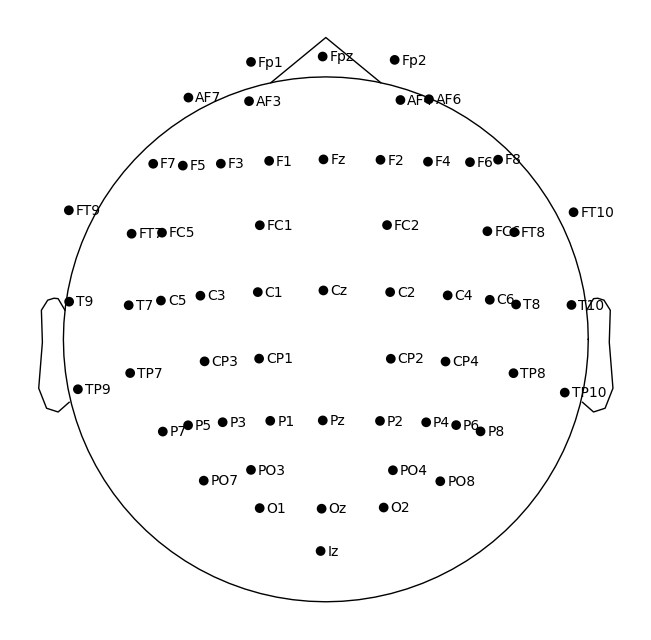

Found in montage: {'O1', 'FC6', 'AF7', 'P4', 'PO4', 'P6', 'F4', 'FC2', 'C1', 'FT7', 'F6', 'P1', 'Fp1', 'Fp2', 'FC1', 'F7', 'P2', 'CP2', 'CP1', 'F3', 'O2', 'FT10', 'T10', 'C2', 'C4', 'PO8', 'T7', 'C6', 'AF3', 'C5', 'C3', 'TP10', 'Fpz', 'TP8', 'AF4', 'F1', 'FT8', 'Oz', 'Fz', 'FC5', 'PO7', 'T8', 'Cz', 'CP3', 'Iz', 'F2', 'T9', 'PO3', 'AF6', 'F5', 'Pz', 'P8', 'P7', 'P3', 'P5', 'TP7', 'FT9', 'TP9', 'F8', 'CP4'}
Missing in montage:    set()


In [ ]:
# 2) Montage

montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='ignore')

# Visualization of sensors
print(raw.info['dig'])
raw.plot_sensors(show_names=True)

# Checking for missing sensors
montage_chs = set(montage.ch_names)
eeg_chs = set(raw.copy().pick('eeg').ch_names)
print("Found in montage:", eeg_chs & montage_chs)
print("Missing in montage:   ", eeg_chs - montage_chs)

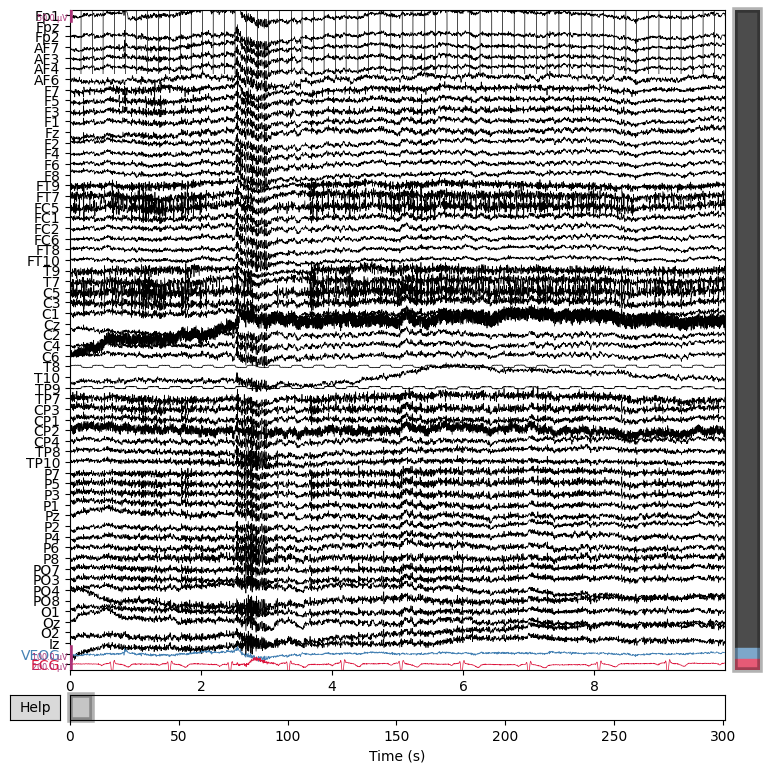

In [ ]:
# 3) Plotting

raw.plot(
    n_channels=62,
    scalings=dict(eeg=25e-6, eog=50e-6, ecg=100e-6),
    color=dict(eeg='black', eog='steelblue', ecg='crimson'),
    title="sub-1983 — raw signal pre-processing",
    block=True
)

plt.show()

In [ ]:
# 4) Bad channels

raw.info['bads'] = []

# Upon simple visual inspection
visual_bads = ['Fpz', 'T8', 'TP9']

# Upon automated inspection by PyPrep
nd = NoisyChannels(raw, random_state=42)
nd.find_all_bads()

print("Bad by deviation:        ", nd.bad_by_deviation)
print("Bad by correlation:      ", nd.bad_by_correlation)
print("Bad by RANSAC:           ", nd.bad_by_ransac)
print("Bad by HF noise:         ", nd.bad_by_hf_noise)
print("Bad by SNR:              ", nd.bad_by_SNR)
print("Bad by flat/NaN:         ", nd.bad_by_nan)
print("Bad by PSD:              ", nd.bad_by_psd)
print("Bad by dropout:          ", nd.bad_by_dropout)
print("─" * 40)
print("Total (union):           ", nd.get_bads())

raw.info['bads'] = list(set(nd.get_bads()) | set(visual_bads))

In [ ]:
# 5) Interpolate bad channels
raw.interpolate_bads(reset_bads=True)

print(f"Channels after interpolation: {raw.info['nchan']}")
print(f"Remaining bads: {raw.info['bads']}")

In [ ]:
# 6) Bandpass filter
raw.filter(0.5, 45, fir_design='firwin', skip_by_annotation='edge')

# Notch filter to remove electrical line noise (60 Hz or 50 Hz depending on the region)
# raw.notch_filter(60, fir_design='firwin', skip_by_annotation='edge')

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


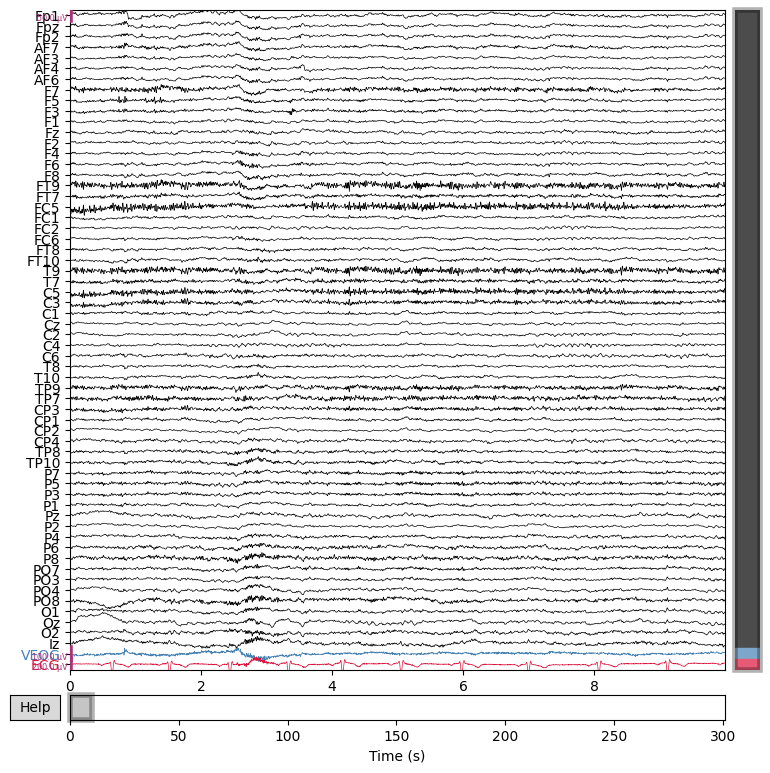

In [ ]:
# 7) Re-reference to channel average
raw.set_eeg_reference('average', projection=False)

raw.plot(
    n_channels=62,
    scalings=dict(eeg=25e-6, eog=50e-6, ecg=100e-6),
    color=dict(eeg='black', eog='steelblue', ecg='crimson'),
    title="sub-1983 — pre-processed signal",
    block=True
)

plt.show()

In [ ]:
# 8) Independent Component Analysis
# Estimated processing time: 1~2 minutes

# Temporary 1 Hz filter for ICA
raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)

# Define the ICA
ica = ICA(
    n_components=None,
    method='infomax',
    fit_params=dict(extended=True),
    random_state=42,
    max_iter='auto'
)

# Fitting
ica.fit(raw_for_ica, picks='eeg')
print(f"ICA fitted: {ica.n_components_} components")

In [ ]:
# Detecting physiological artifacts via ICLabel (pre-trained model)
# Estimated processing time: 30 seconds

# ICLabel - classify all components
labels = label_components(raw, ica, method='iclabel')

print("\nComponents and classifications:")
for i, (label, proba) in enumerate(zip(labels['labels'], labels['y_pred_proba'])):
    conf = proba.max()
    print(f"  IC {i:02d}: {label:20s} (confidence: {conf:.2f})")

# Mark for exclusion
exclude_labels = ['eye blink', 'heart beat', 'muscle artifact',
                  'line noise', 'channel noise']

ica.exclude = [
    i for i, (label, proba) in enumerate(
        zip(labels['labels'], labels['y_pred_proba'])
    )
    if label in exclude_labels and proba.max() > 0.7
]

print(f"\nExcluded ({len(ica.exclude)}): {ica.exclude}")
print(f"Labels: {[labels['labels'][i] for i in ica.exclude]}")

# Inspect before applying
ica.plot_components(picks=ica.exclude)
plt.show()

In [ ]:
# Apply ICA
ica.apply(raw)

# Re-apply the original filter
raw.filter(l_freq=0.5, h_freq=45.0, verbose=False)

print(raw.info['highpass'])
print(raw.info['lowpass'])

In [ ]:
# Summary of removed components
print("  ICA Summary\n")
print(f"  Total components : {ica.n_components_}")
print(f"  Removed components: {len(ica.exclude)}")
print(f"  Kept components : {ica.n_components_ - len(ica.exclude)}")
print()
for i in ica.exclude:
    label = labels['labels'][i]
    conf  = labels['y_pred_proba'][i].max()
    print(f"  IC {i:02d} → {label:20s} (confidence: {conf:.2f})")
print("=" * 50)

  ICA Summary

  Total components : 48
  Removed components: 6
  Kept components : 42

  IC 00 → eye blink            (confidence: 0.93)
  IC 01 → eye blink            (confidence: 1.00)
  IC 08 → muscle artifact      (confidence: 0.96)
  IC 11 → muscle artifact      (confidence: 0.91)
  IC 14 → muscle artifact      (confidence: 0.78)
  IC 41 → muscle artifact      (confidence: 0.80)


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.192 (s)


/tmp/ipykernel_839/1903277153.py:6: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_original.compute_psd(fmin=1, fmax=45).plot(


Plotting power spectral density (dB=True).


/tmp/ipykernel_839/1903277153.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


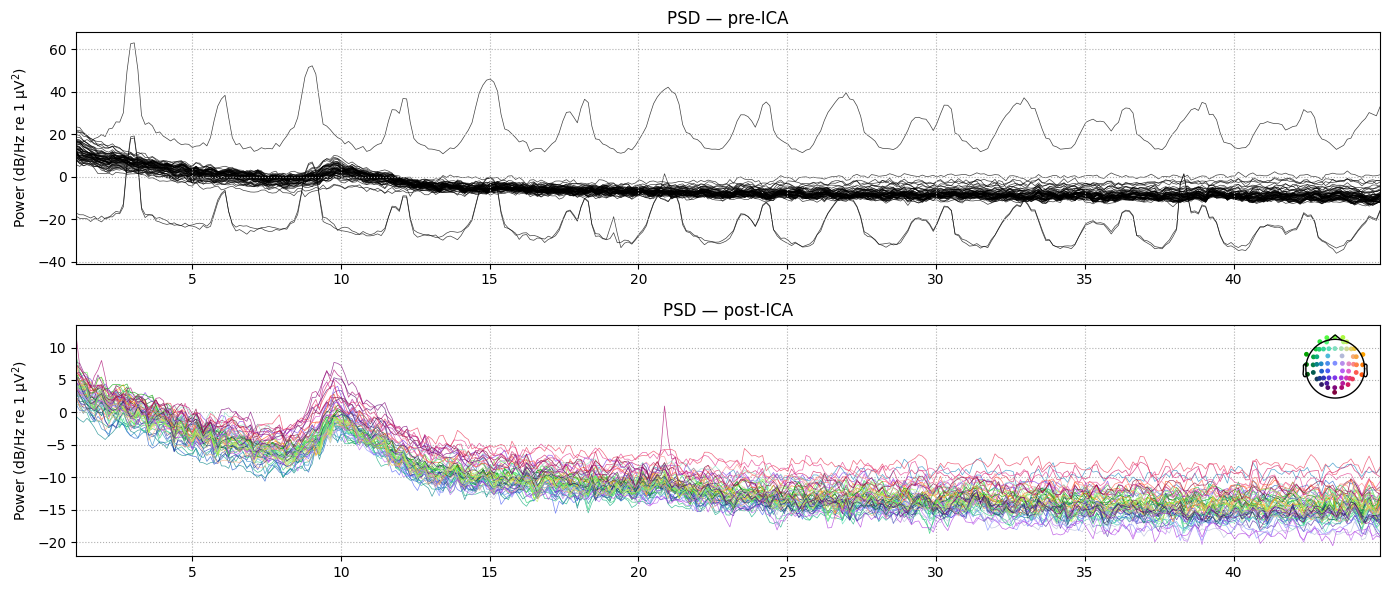

In [ ]:
# 9) Preprocessing verification with Power Spectral Density (PSD)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Pre-ICA PSD
raw_original.compute_psd(fmin=1, fmax=45).plot(
    axes=axes[0], show=False
)
axes[0].set_title("PSD — pre-ICA")

# Post-ICA PSD
raw.compute_psd(fmin=1, fmax=45).plot(
    axes=axes[1], show=False
)
axes[1].set_title("PSD — post-ICA")

plt.tight_layout()
plt.show()

In [ ]:
# 10) Epoch segmentation (2 seconds)

epochs = mne.make_fixed_length_epochs(
    raw,
    duration=2.0,    # 2-second windows
    overlap=0.0,     # no overlap
    preload=True,
    verbose=False
)
print(f"Epochs created: {len(epochs)}")
print(f"Shape: {epochs.get_data().shape}")

In [ ]:
# Automatic threshold via autoreject
reject = get_rejection_threshold(epochs.copy().pick('eeg'), verbose=False)
print(f"EEG threshold: {reject}")

epochs.drop_bad(reject=reject)
print(f"Remaining epochs: {len(epochs)}")

In [ ]:
# 11) Feature extraction

# Define function to extract entropy features
def compute_entropy_features(signal):
    """6 entropy features."""

    def tsallis_entropy(x, q=2):
        hist, _ = np.histogram(x, bins=100, density=True)
        hist = hist[hist > 0]
        if q == 1:
            return -np.sum(hist * np.log2(hist))
        return (1 - np.sum(hist**q)) / (q - 1)

    def shannon_entropy(x):
        hist, _ = np.histogram(x, bins=100, density=True)
        hist = hist[hist > 0]
        return -np.sum(hist * np.log2(hist))

    def logenergy_entropy(x):
        hist, _ = np.histogram(x, bins=100, density=True)
        hist = hist[hist > 0]
        return np.sum((np.log2(hist))**2)

    def renyi_entropy(x, alpha=2):
        hist, _ = np.histogram(x, bins=100, density=True)
        hist = hist[hist > 0]
        if alpha == 1:
            return -np.sum(hist * np.log2(hist))
        return (1 / (1 - alpha)) * np.log2(np.sum(hist**alpha))

    return {
        'tsallis_q2':    tsallis_entropy(signal, q=2),
        'tsallis_q3':    tsallis_entropy(signal, q=3),
        'shannon':       shannon_entropy(signal),
        'logenergy':     logenergy_entropy(signal),
        'renyi_a2':      renyi_entropy(signal, alpha=2),
        'renyi_a3':      renyi_entropy(signal, alpha=3),
    }

In [ ]:
# Define function to extract statistical features
def compute_statistical_features(signal):
    """17 statistical features."""

    first_diff  = np.diff(signal)
    second_diff = np.diff(first_diff)

    # Hjorth parameters
    activity   = np.var(signal)
    var_d1     = np.var(first_diff)
    var_d2     = np.var(second_diff)
    mobility   = np.sqrt(var_d1 / activity) if activity > 0 else 0
    complexity = (np.sqrt(var_d2 / var_d1) / mobility
                  if (var_d1 > 0 and mobility > 0) else 0)

    # Mean Teager Energy
    teager = signal[1:-1]**2 - signal[:-2] * signal[2:]
    mean_teager_energy = np.mean(teager)

    # LRSSV
    lrssv = np.log(np.sqrt(np.sum(first_diff**2)) + 1e-10)

    return {
        'mean':                    np.mean(signal),
        'median':                  np.median(signal),
        'std':                     np.std(signal),
        'skewness':                stats.skew(signal),
        'kurtosis':                stats.kurtosis(signal),
        'maximum':                 np.max(signal),
        'minimum':                 np.min(signal),
        'first_diff':              np.mean(np.abs(first_diff)),
        'norm_first_diff':         np.mean(np.abs(first_diff)) / (np.std(signal) + 1e-10),
        'second_diff':             np.mean(np.abs(second_diff)),
        'norm_second_diff':        np.mean(np.abs(second_diff)) / (np.std(signal) + 1e-10),
        'mean_energy':             np.mean(signal**2),
        'mean_teager_energy':      mean_teager_energy,
        'lrssv':                   lrssv,
        'hjorth_activity':         activity,
        'hjorth_mobility':         mobility,
        'hjorth_complexity':       complexity,
    }

In [ ]:
# Define function to extract frequency band features

def compute_frequency_features(signal, sfreq=250):
    """15 frequency features."""

    # AR model order 10
    try:
        ar_model = AutoReg(signal, lags=10, old_names=False).fit()
        ar_coeffs = ar_model.params[1:11]  # 10 coefficients
    except Exception:
        ar_coeffs = np.zeros(10)

    # PSD via Welch for frequency band power
    freqs, psd = welch(signal, fs=sfreq, nperseg=min(256, len(signal)))

    def band_power(fmin, fmax):
        idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
        return np.mean(psd[idx]) if len(idx) > 0 else 0

    alpha = band_power(8,  13)
    beta  = band_power(13, 30)
    delta = band_power(1,  4)
    theta = band_power(4,  8)
    alpha_theta_ratio = alpha / (theta + 1e-10)

    features = {f'ar_{i+1}': v for i, v in enumerate(ar_coeffs)}
    features.update({
        'power_delta':          delta,
        'power_theta':          theta,
        'power_alpha':          alpha,
        'power_beta':           beta,
        'alpha_theta_ratio':    alpha_theta_ratio,
    })
    return features

In [ ]:
# Define function to extract all combined features
def extract_all_features(signal, sfreq=250):
    """Combines the 38 features for a single channel."""
    features = {}
    features.update(compute_entropy_features(signal))
    features.update(compute_statistical_features(signal))
    features.update(compute_frequency_features(signal, sfreq))
    return features

In [ ]:
# Features for single subject

# Dictionary for this subject
subject_row = {}

# Load subject data
dataset, group, task = SUBJECTS[subject_id]
label = 1 if group == 'Psychosis' else 0

eeg_data = raw.get_data(picks='eeg')  # (n_channels, n_samples)
eeg_chs = raw.copy().pick('eeg').ch_names
sfreq = raw.info['sfreq']

# For each channel, extract features and add as columns
for ch_idx, ch_name in enumerate(eeg_chs):
    signal = eeg_data[ch_idx, :]  # full channel signal
    feats = extract_all_features(signal, sfreq)  # your function intact!

    # Add each feature with name feature_channel
    for feat_name, feat_value in feats.items():
        col_name = f"{feat_name}_{ch_name}"
        subject_row[col_name] = feat_value

# Add identifying columns
subject_row['subject_id'] = subject_id
subject_row['group'] = group
subject_row['label'] = label

# DataFrame
df_sub = pd.DataFrame([subject_row])
print(f"Shape: {df_sub.shape}\n")
# Expected: (1 row, 38 features x 60 channels + 3 metadata) = (1, 2283)
print(df_sub)

Shape: (1, 2283)

   tsallis_q2_Fp1  tsallis_q3_Fp1   shannon_Fp1  logenergy_Fp1  renyi_a2_Fp1  \
0   -1.115242e+11   -4.149610e+15 -2.774466e+07   12877.883041    -36.698566   

   renyi_a3_Fp1      mean_Fp1    median_Fp1   std_Fp1  skewness_Fp1  ...  \
0    -26.440949  1.172605e-10  5.691808e-08  0.000005     -0.175356  ...   

    ar_9_Iz  ar_10_Iz  power_delta_Iz  power_theta_Iz  power_alpha_Iz  \
0  5.555086 -0.769614    1.886041e-12    6.822252e-13    7.760030e-13   

   power_beta_Iz  alpha_theta_ratio_Iz  subject_id      group  label  
0   1.310526e-13              0.007707    sub-1983  Psychosis      1  

[1 rows x 2283 columns]


In [ ]:
# Check for missing and infinite values
print("Missing data")
print(f"NaN: {df_sub.isnull().sum().sum()}")
print(f"Inf: {np.isinf(df_sub.select_dtypes(include=np.number)).sum().sum()}")

<br>

#### **Full dataset**

Now we will perform the same preprocessing pipeline applied to the full dataset (n=143). Datasets 1 and 2 have differences in their channels, which requires an additional step of selecting common channels before anything else.

1) Selection of common channels (48 out of 60).
2) Define a complete preprocessing function, with all steps embedded.
3) Run a loop with 143 subjects and save the final result in a dataframe.
<br>


**The estimated processing time to process all subjects is 6 hours.**

<br>

In [ ]:
# Checking common channels between dataset 1 and 2
def get_common_channels():
    """Identifies the common EEG channels between ds003944 and ds003947."""

    # Take one subject from each dataset already loaded
    sample_44 = load_raw('sub-1983')
    sample_47 = load_raw('sub-2246A')

    ch_44 = set(sample_44.copy().pick('eeg').ch_names)
    ch_47 = set(sample_47.copy().pick('eeg').ch_names)

    common = sorted(ch_44 & ch_47)
    print(f"Common channels: {len(common)}")
    print(f"Excluded from ds003944: {sorted(ch_44 - ch_47)}")
    print(f"Excluded from ds003947: {sorted(ch_47 - ch_44)}")
    return common

common_channels = get_common_channels()

print(common_channels)
print(type(common_channels))

# Define montage (again)
montage = mne.channels.make_standard_montage('standard_1020')

In [ ]:
# Define function for complete preprocessing per subject

def preprocess_subject(subject_id):
    """Complete pipeline for a single subject. Returns a feature DataFrame."""

    dataset, group, task = SUBJECTS[subject_id]
    label = 1 if group == 'Psychosis' else 0

    # 1) Load
    raw = load_raw(subject_id)

    # 2) Montage
    raw.set_montage(montage, match_case=False, on_missing='ignore')

    # 3) Bad channels
    raw.info['bads'] = []
    nd = NoisyChannels(raw, random_state=42)
    nd.find_all_bads()
    raw.info['bads'] = nd.get_bads()

    # 4) Interpolation
    raw.interpolate_bads(reset_bads=True)

    # 5) Band-pass filter
    raw.filter(0.5, 45, fir_design='firwin',
               skip_by_annotation='edge', verbose=False)

    # 6) Re-referencing
    raw.set_eeg_reference('average', projection=False, verbose=False)

    # 7) ICA
    raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)
    ica = ICA(n_components=None, method='infomax',
              fit_params=dict(extended=True),
              random_state=42, max_iter='auto')
    ica.fit(raw_for_ica, picks='eeg')
    del raw_for_ica

    labels_ica = label_components(raw, ica, method='iclabel')
    ica.exclude = [
        i for i, (lbl, proba) in enumerate(
            zip(labels_ica['labels'], labels_ica['y_pred_proba'])
        )
        if lbl in exclude_labels and proba.max() > 0.7  # reuses exclude_labels
    ]
    ica.apply(raw, verbose=False)
    raw.filter(l_freq=0.5, h_freq=45.0, verbose=False)

    # 8) Epoching
    epochs = mne.make_fixed_length_epochs(
        raw, duration=2.0, overlap=0.0, preload=True, verbose=False
    )

    # 9) Epoch rejection
    reject = get_rejection_threshold(epochs.copy().pick('eeg'), verbose=False)
    epochs.drop_bad(reject=reject, verbose=False)

    # 10) Feature extraction
    eeg_data = raw.get_data(picks=common_channels)  # common channels between datasets
    eeg_chs = common_channels
    sfreq = raw.info['sfreq']

    # Dictionary for this subject
    subject_row = {}

    # For each channel, extract features and add as columns
    for ch_idx, ch_name in enumerate(eeg_chs):
        signal = eeg_data[ch_idx, :]  # full channel signal
        feats = extract_all_features(signal, sfreq)

        # Add each feature with name feature_channel
        for feat_name, feat_value in feats.items():
            col_name = f"{feat_name}_{ch_name}"
            subject_row[col_name] = feat_value

    # Add identifying columns
    subject_row['subject_id'] = subject_id
    subject_row['group'] = group
    subject_row['label'] = label

    # DataFrame
    df_subject = pd.DataFrame([subject_row])

    return df_subject

In [ ]:
# Run loop with 143 subjects
# Total processing time: 5h30 ~ 6h

RESULTS_PATH = '/content/eeg_features.csv'
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

all_dfs  = []
failed   = []
done_ids = set()

# Resume from where it stopped if the CSV already exists
if os.path.exists(RESULTS_PATH):
    df_done  = pd.read_csv(RESULTS_PATH)
    done_ids = set(df_done['subject_id'].unique())
    all_dfs.append(df_done)
    print(f"Resuming: {len(done_ids)} subjects already processed.")

pending = [s for s in SUBJECTS if s not in done_ids]
print(f"Pending: {len(pending)} subjects\n")

for i, subject_id in enumerate(pending):
    try:
        df_sub = preprocess_subject(subject_id)
        all_dfs.append(df_sub)

        # Checkpoint every 5 subjects
        if (i + 1) % 5 == 0 or (i + 1) == len(pending):
            df_all = pd.concat(all_dfs, ignore_index=True)
            df_all.to_csv(RESULTS_PATH, index=False)
            print(f"[{i+1:02d}/{len(pending)}] ✓ {subject_id} "
                  f"| {len(df_sub)} rows "
                  f"| checkpoint saved ({len(df_all)} rows total)")
        else:
            print(f"[{i+1:02d}/{len(pending)}] ✓ {subject_id} "
                  f"| {len(df_sub)} rows")

    except Exception as e:
        failed.append((subject_id, str(e)))
        print(f"[{i+1:02d}/{len(pending)}] ✗ {subject_id}: {e}")

In [ ]:
# Final result
df_final = pd.concat(all_dfs, ignore_index=True)
df_final.to_csv(RESULTS_PATH, index=False)

print(f"\n  Completed: {len(done_ids) + len(pending) - len(failed)} subjects")
print(f"  Failures ({len(failed)}): {[s for s, _ in failed]}")
print(f"  Final dataset: {df_final.shape}")  # Expected: (143, 1827)
print(f"  Saved to: {RESULTS_PATH}")

<br>


---


### <font color=#4682b4>**Part 3 - Exploratory Data Analysis**</font>

With the data properly preprocessed and the features extracted into a tabular dataset, we will conduct a brief exploratory analysis. We will inspect:

- Missing values.
- Datatypes of features and target variable.
- Distribution of values for each feature (min/max/mean/sd).
- Distribution of the target variable.
- Outliers (iqr * 5).
- Normality of features by group (psychosis/control).
- Homoscedasticity of features.
- Correlation between features (heatmap).
- Mean differences between groups.

<br>

In [ ]:
# Download the feature dataset

# Direct download via GitHub URL
url = "https://raw.githubusercontent.com/pedrof0rtes/eeg-psychosis/refs/heads/main/eeg_features.csv"
local_path = "/content/eeg_features.csv"

urllib.request.urlretrieve(url, local_path)
print("Download complete!")

# Importing the dataset
data = pd.DataFrame(
    pd.read_csv(local_path)
)

In [ ]:
# Initial exploration

feature_cols = [c for c in data.columns
                if c not in ('subject_id', 'group', 'label')]

# Preliminary exploration
print(f"Shape: {data.shape}\n")
print(f"Groups: {data['group'].value_counts().to_dict()}\n")
print(f"Infinite values: {np.isinf(data.select_dtypes(include=np.number)).sum().sum()}\n")
print(f"Missing values: {data.isnull().sum().sum()}\n")
print(f"Duplicate values: {data.duplicated().sum()}\n")
print(f"Datatype of feature variables: {data[feature_cols].dtypes.unique()}\n")
print(f"Datatype of target variable: {data['label'].dtypes}\n")
print("Min, max and mean values: \n")
data[data.columns[:38]].describe().T

Shape: (143, 1827)

Groups: {'Psychosis': 81, 'Control': 62}

Infinite values: 0

Missing values: 0

Duplicate values: 0

Datatype of feature variables: [dtype('float64')]

Datatype of target variable: int64

Min, max and mean values: 



,count,mean,std,min,25%,50%,75%,max
tsallis_q2_AF3,143.0,-6.885394e+10,5.845678e+10,-2.784500e+11,-8.168767e+10,-5.138294e+10,-3.079809e+10,-3.986873e+09
tsallis_q3_AF3,143.0,-2.512725e+15,2.963030e+15,-1.467395e+16,-2.838203e+15,-1.552430e+15,-7.190192e+14,-5.670554e+13
shannon_AF3,143.0,-1.868205e+07,1.067900e+07,-5.302781e+07,-2.307738e+07,-1.666880e+07,-1.192613e+07,-1.374336e+06
logenergy_AF3,143.0,1.027619e+04,2.970263e+03,1.890953e+03,8.331928e+03,1.036690e+04,1.231142e+04,1.751625e+04
renyi_a2_AF3,143.0,-3.553832e+01,1.219655e+00,-3.801863e+01,-3.624940e+01,-3.558057e+01,-3.484204e+01,-3.189261e+01
renyi_a3_AF3,143.0,-2.567483e+01,8.080184e-01,-2.735205e+01,-2.616695e+01,-2.573172e+01,-2.517641e+01,-2.334428e+01
mean_AF3,143.0,-2.351279e-09,1.872775e-08,-1.238133e-07,-1.144606e-08,-1.510021e-09,7.212376e-09,4.970968e-08
median_AF3,143.0,-7.616670e-08,1.683264e-07,-1.131235e-06,-9.515906e-08,-3.824749e-08,8.364663e-09,2.061574e-07
std_AF3,143.0,7.015283e-06,3.075107e-06,3.195139e-06,5.103922e-06,6.214085e-06,8.357163e-06,2.388837e-05
skewness_AF3,143.0,3.202891e-02,8.980491e-01,-6.731304e+00,-8.289893e-02,4.422380e-02,2.477211e-01,5.953160e+00


<br>

**A good overview so far:**

* There are no missing, infinite, or duplicate values in the feature dataset.

* All 143 subjects were correctly extracted.

* The 38 features were correctly extracted for each channel, resulting in **38 x 48 = 1824 columns**. In addition to these variables, there are 2 identification columns and 1 target variable:

  *"subject_id", "group", "label"*

* The features are already of type "float", and the target variable "label" is already of type "int". This will be important later on when training the models.

* There is a **slight class imbalance**, with the psychosis group being 30% larger than the control group.

**<font color=#BA1B15>Attention</font>**:

The attributes were calculated for each EEG channel, with a total of 48 channels. This resulted in a high-dimensional dataset, where we have far more features than observations (38x48=1824).

**Important implications:**

1) For the remainder of the exploratory analysis, we will use a grouped dataset. The average across all channels will be calculated for each feature, **resulting in 38 feature columns.**

2) For the subsequent model training, it will be imperative to perform a **feature selection** step.

<br>

In [ ]:
# New grouped dataframe

# Identify non-feature columns
non_feature_cols = ['subject_id', 'group', 'label']
feature_cols = [c for c in data.columns if c not in non_feature_cols]

# Extract the feature name from each column
feat_names = pd.Series(feature_cols).str.rsplit('_', n=1).str[0]
col_to_feat = dict(zip(feature_cols, feat_names))

# Group columns by feature and take the mean
data_grouped = (
    data[feature_cols]
    .T.groupby(col_to_feat).mean().T
)
data_grouped[['subject_id', 'group', 'label']] = data[['subject_id', 'group', 'label']]

# Restore original ordering (entropy, statistical, frequency)
data_grouped = data_grouped[non_feature_cols + feat_names.unique().tolist()]

# Separated version without identification columns
data_clean = data_grouped.drop(["subject_id", "group", "label"], axis=1)

print(f"Original shape: {data.shape}")
print(f"Grouped shape: {data_grouped.shape}")
print(f"\nFirst rows:")
print(data_grouped.head())

<br>

#### **Outliers, Normality and Homoscedasticity**

Let's check for the presence of extreme outliers **(5*IQR)**, normality of each feature in both groups, and homogeneity of variance for each feature between the two groups (homoscedasticity).


<br>

In [ ]:
# Checking for extreme outliers across all features
outlier_rows = set()

for col in data_clean.columns:
    q1 = data_clean[col].quantile(0.25)
    q3 = data_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - (iqr * 5)
    upper_limit = q3 + (iqr * 5)

    outliers = data_clean[(data_clean[col] > upper_limit) | (data_clean[col] < lower_limit)]
    outlier_rows.update(outliers.index)

    print("Outliers detected in column '{}': {}".format(col, len(outliers.index)))

print("\nTotal rows with outliers detected: '{}'".format(len(outlier_rows)))


outlier_subjects = data_grouped.iloc[list(outlier_rows), 0].values
print(f"Subjects with extreme outliers: {outlier_subjects}")

In [ ]:
# Check normality of features by group
print("\nNormality (D'Agostino-Pearson) by Group:")

normality_list = []

for col in data_clean.columns:
        for group in data_grouped['group'].unique():
            group_data = data_grouped[data_grouped['group'] == group][col].dropna()
            stat, p = normaltest(group_data)

            normality_list.append({
                'feature': col,
                'group': group,
                'statistic': round(stat, 3),
                'p_value': round(p, 3),
                'normal': p > 0.05
            })

normality_df = pd.DataFrame(normality_list).set_index('feature')

# Pivot for easier visualization
normality_pivot = normality_df.pivot(
    columns='group',
    values=['p_value', 'normal']
)

# Extract lists
normal_both = normality_pivot[
    normality_pivot[('normal', 'Psychosis')] & normality_pivot[('normal', 'Control')]
].index.tolist()

non_normal_any = normality_pivot[
    ~(normality_pivot[('normal', 'Psychosis')] & normality_pivot[('normal', 'Control')])
].index.tolist()

# Final prints
print(f"\nFeatures normal in both groups: {len(normal_both)}")
print(normal_both)
print(f"\nFeatures non-normal in at least one group: {len(non_normal_any)}")
print(non_normal_any)

In [ ]:
# Check homoscedasticity of features
print("\nHomoscedasticity (Levene)\n")
homo_results = {}
control   = data_grouped[data_grouped['group'] == "Control"]
psychosis = data_grouped[data_grouped['group'] == "Psychosis"]

for col in data_clean.columns:
    stat, p = levene(
        control[col],
        psychosis[col]
    )
    homo_results[col] = {'stat': stat, 'p': p, 'homoscedastic': p > 0.05}

homo_df = pd.DataFrame(homo_results).T
print("Homoscedastic features:\n")
print(homo_df['homoscedastic'])

<br>

**Observations:**

* **1)** There are 7 subjects with extreme outliers, across 6 distinct features (1 entropy feature, 2 statistical features, 3 frequency features).

* **2)** 14 features present a normal distribution and 24 present a non-normal distribution according to the D'Agostino-Pearson test.

* **3)** All features showed homoscedasticity between psychosis and control groups.
<br>

**For the visual analyses and statistical tests that follow, we will standardize the features using StandardScaler.**

**For subsequent model training, the presence of 7 outlier subjects and 24 non-normal features points to the need for data transformation, in addition to standardization.**

<br>

In [ ]:
feature_cols = [c for c in data_grouped.columns if c not in non_feature_cols]

scaler_eda = StandardScaler()
X_eda = scaler_eda.fit_transform(data_grouped[feature_cols])
data_eda = pd.DataFrame(X_eda, columns=feature_cols)
data_eda['group'] = data_grouped['group'].values
data_eda['subject_id'] = data_grouped['subject_id'].values
data_eda['label'] = data_grouped['label'].values

print(data_eda.head())

<br>

#### **Visualization with boxplots**

Let's visualize the difference between the means of each feature between the psychosis group and the control group. To do this, 38 boxplots will be plotted.

<br>

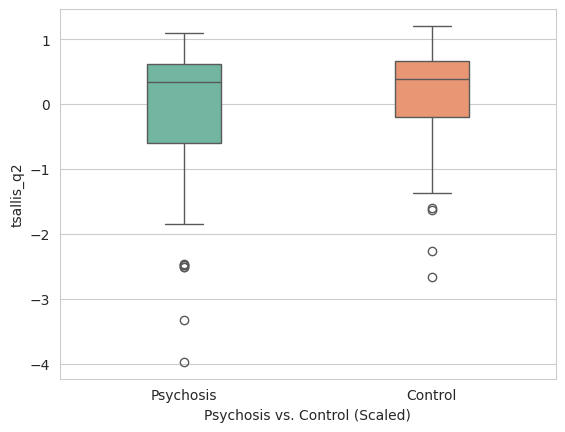

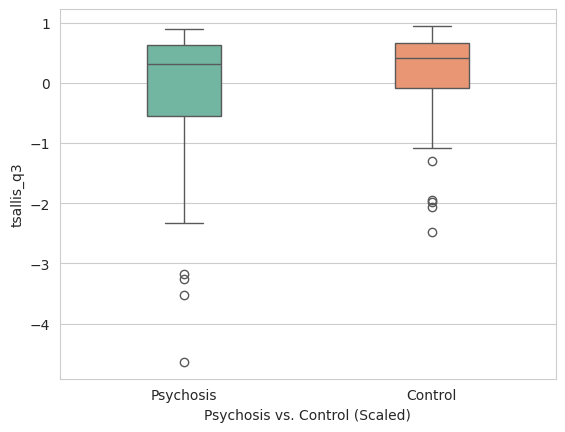

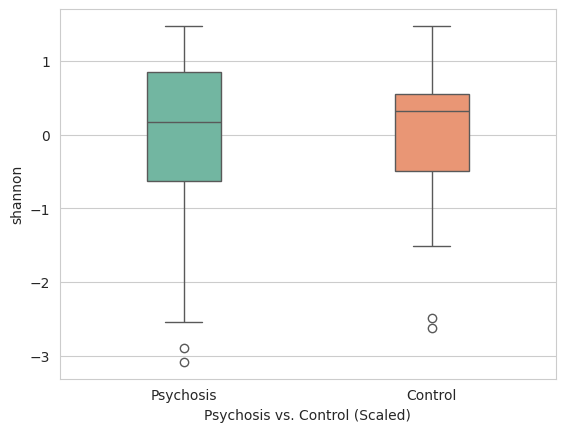

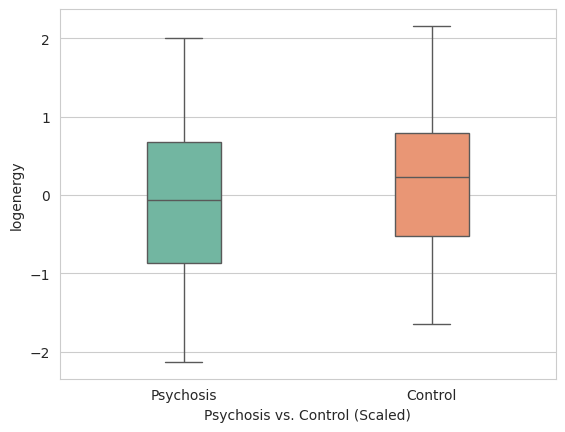

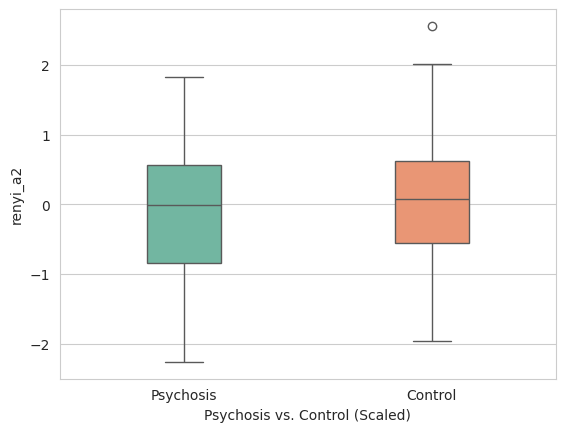

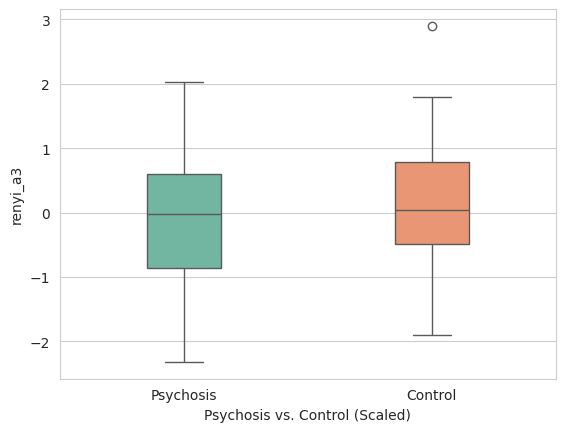

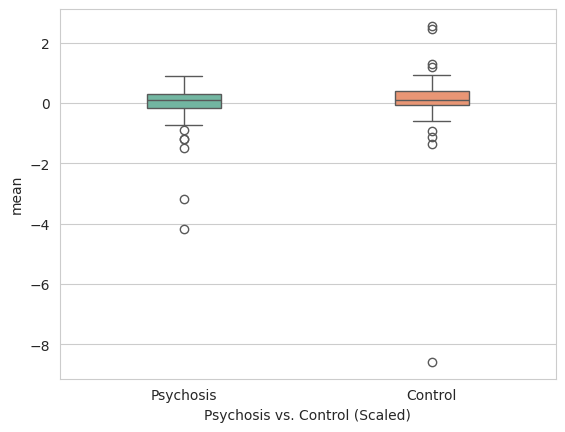

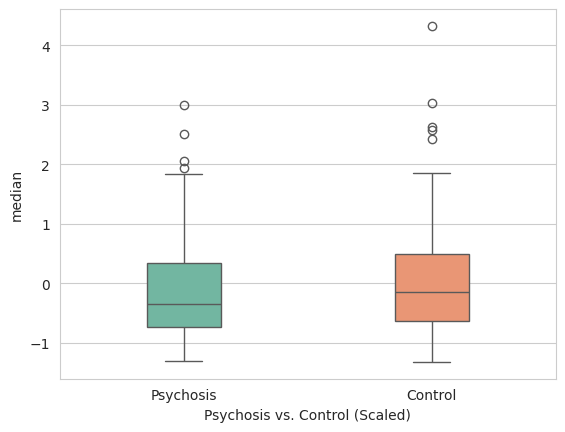

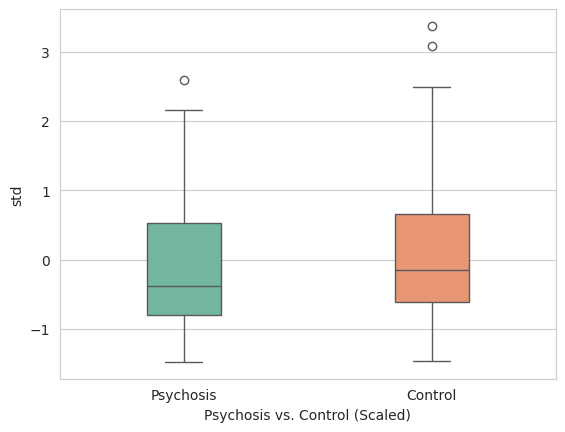

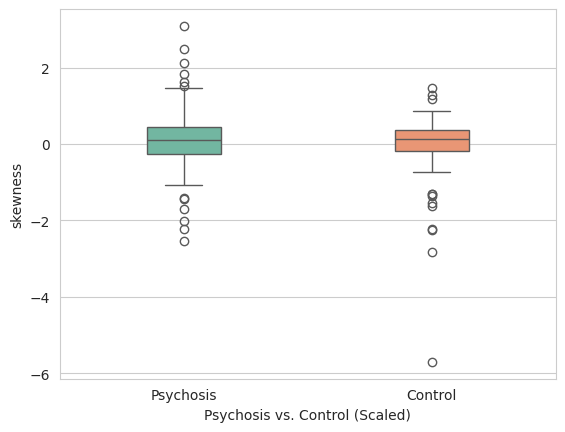

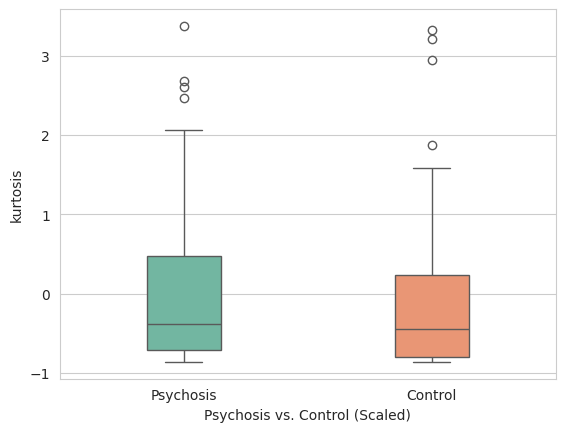

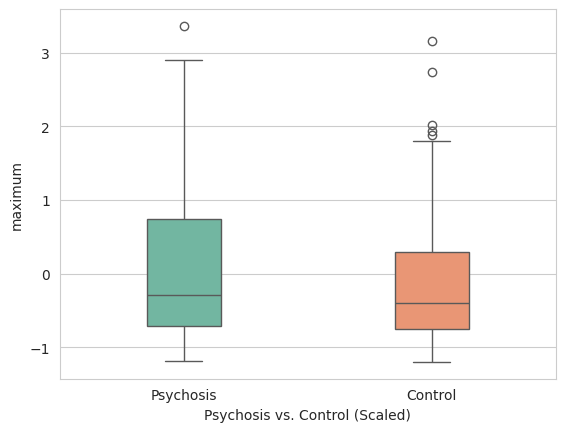

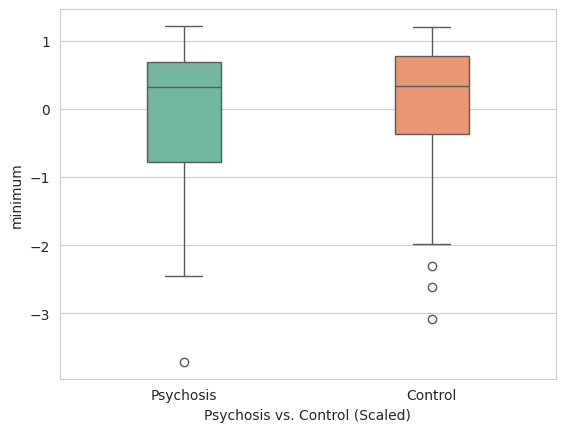

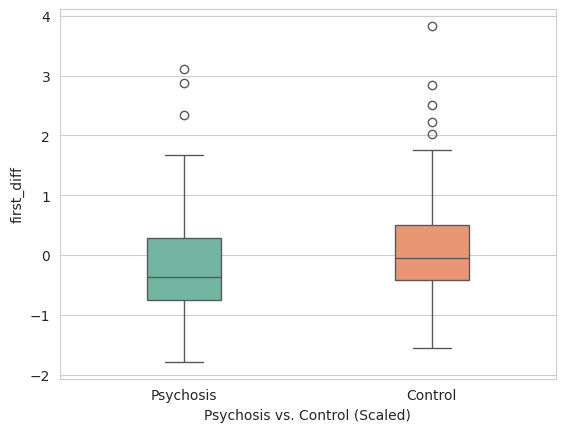

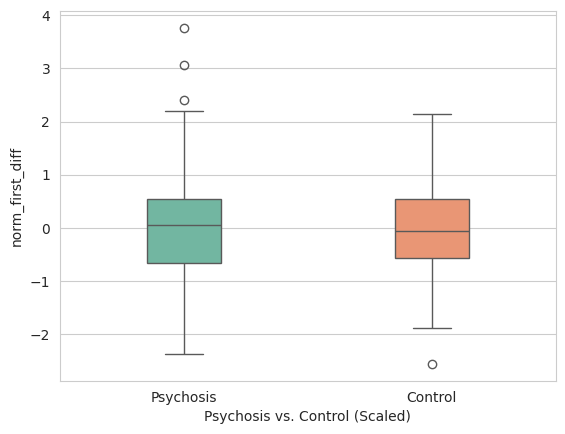

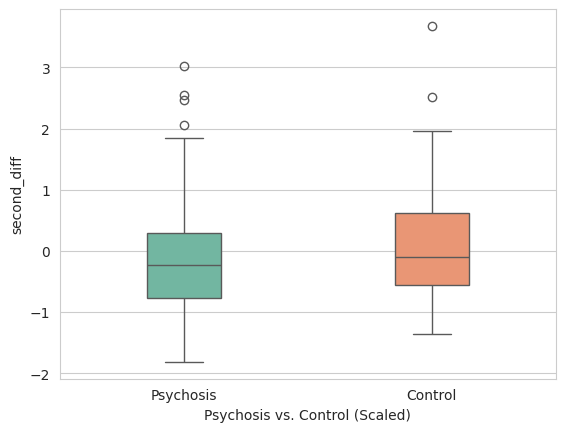

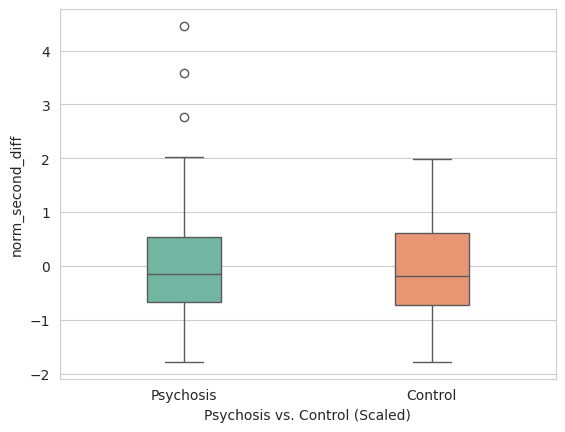

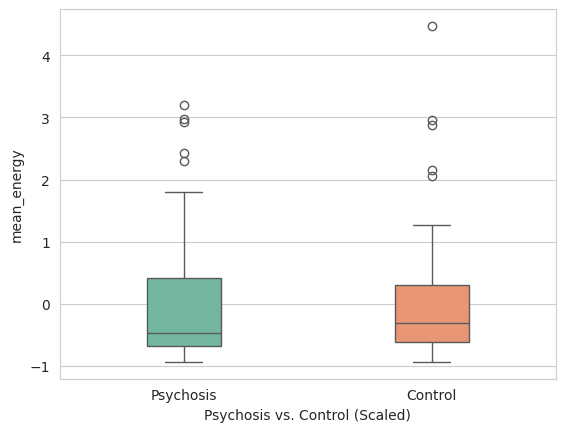

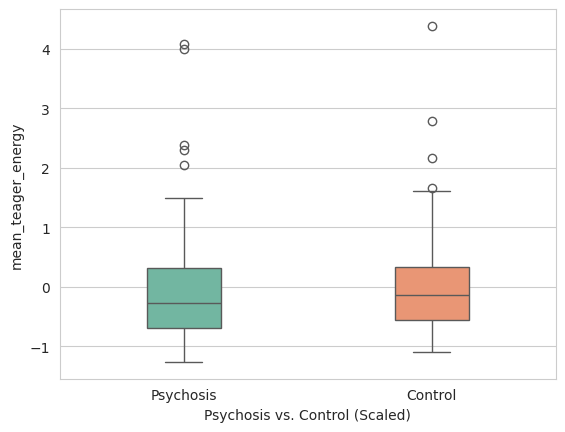

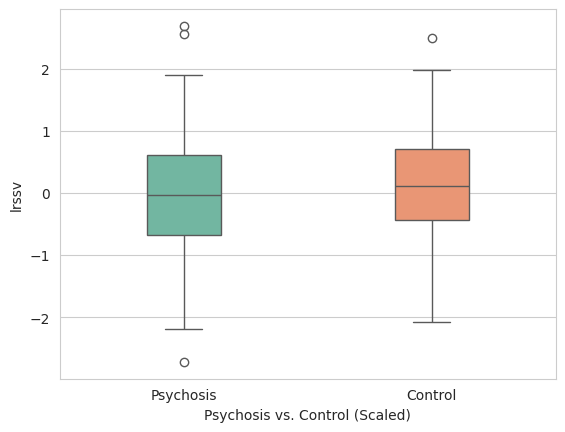

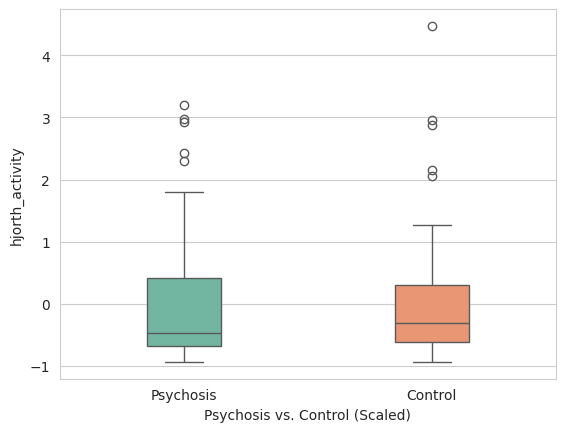

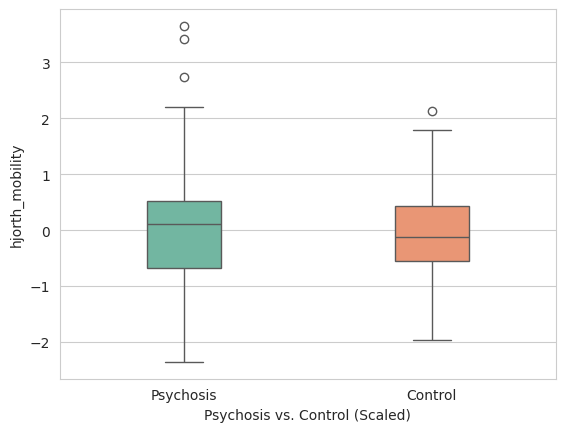

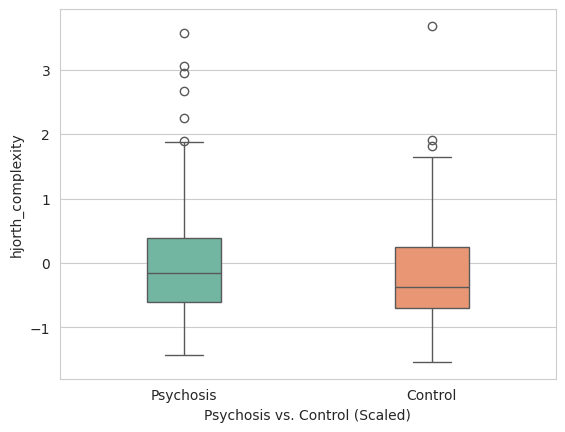

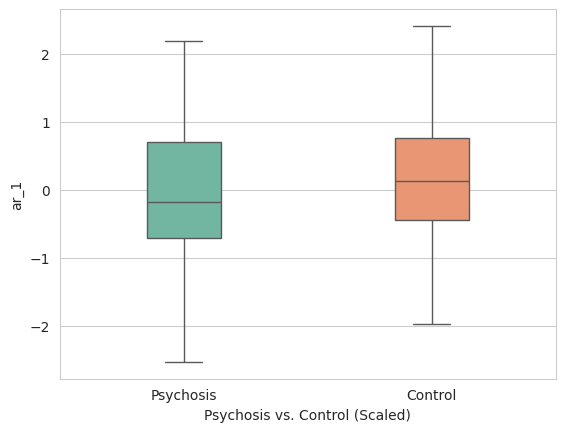

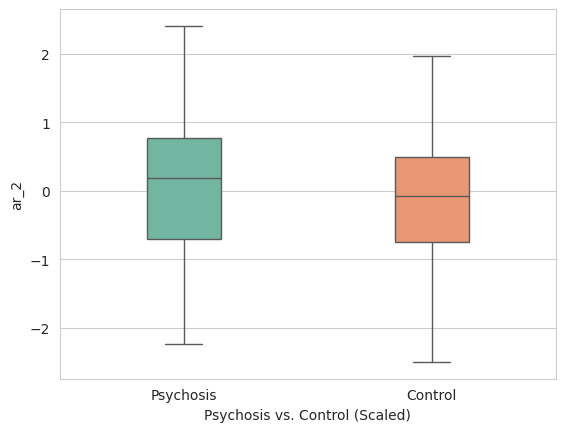

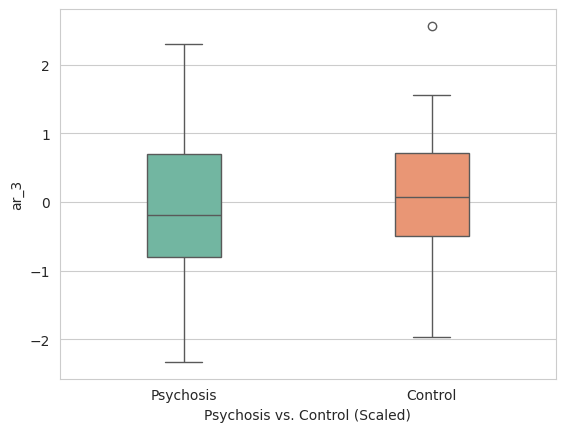

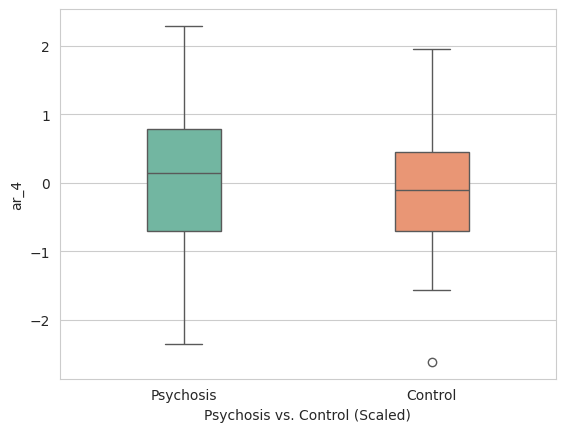

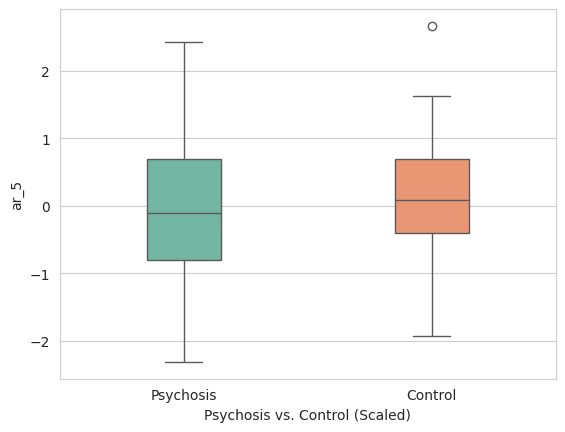

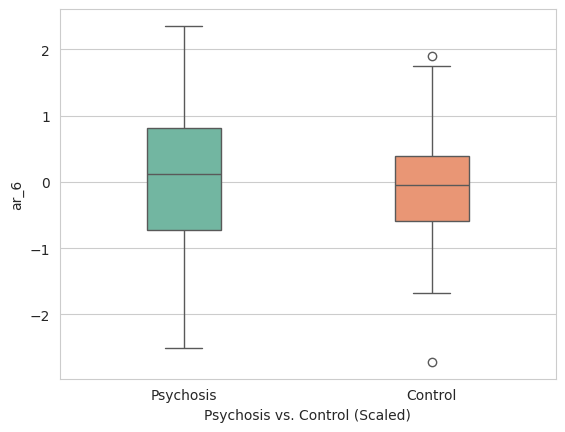

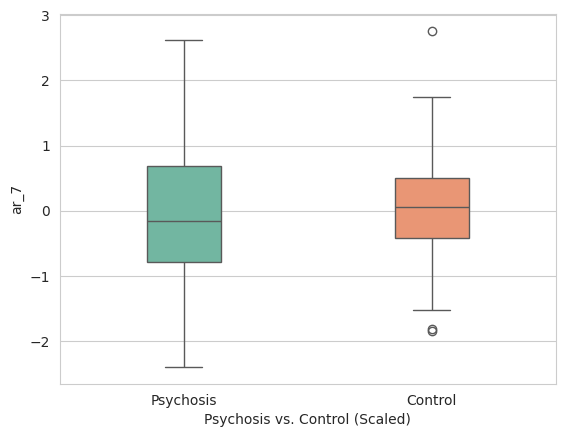

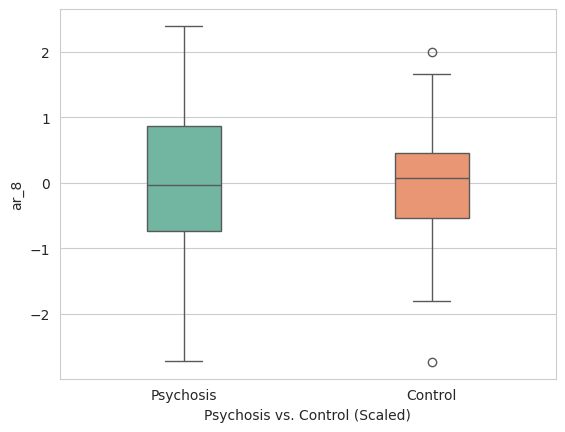

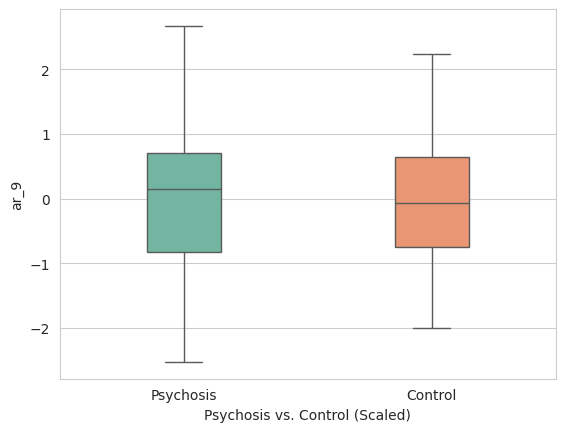

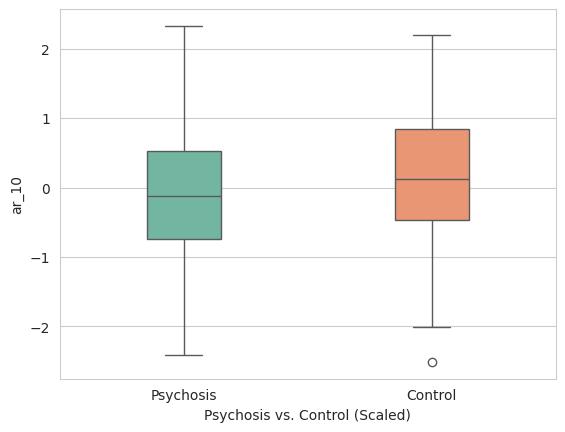

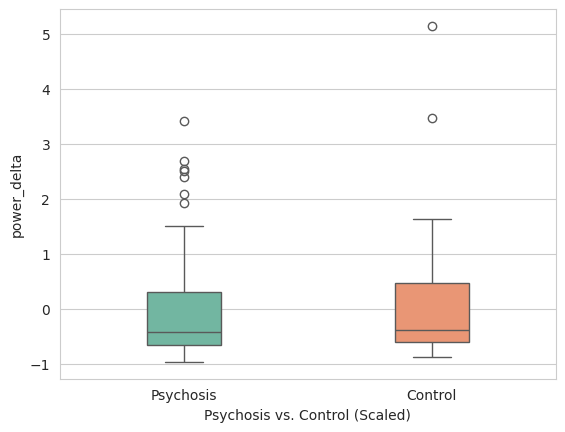

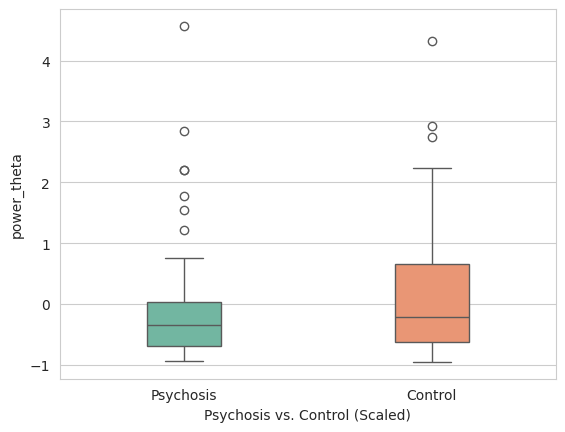

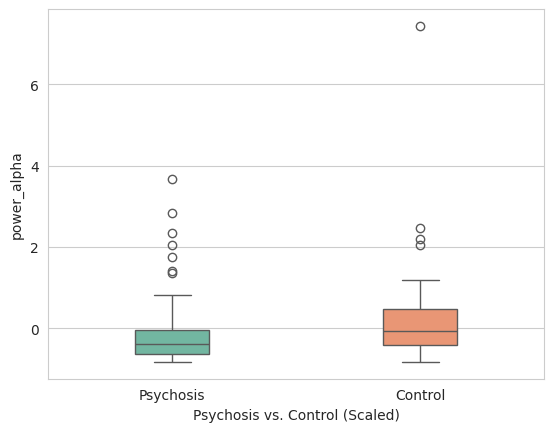

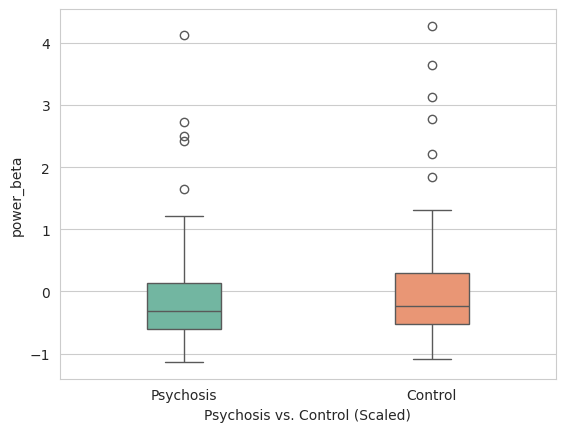

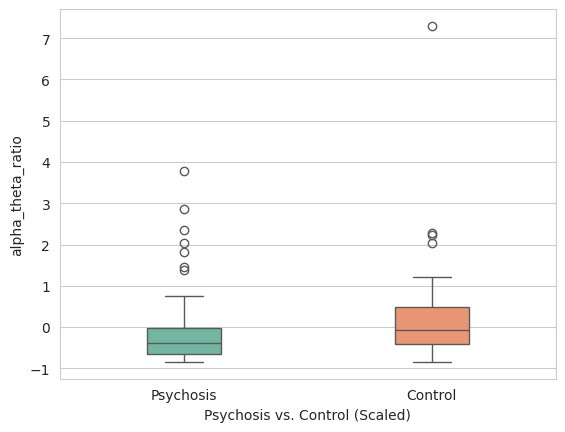

In [ ]:
# Boxplot comparison

sns.set_style("whitegrid")
sns.set_palette("Set2")

for col in feature_cols:
  sns.boxplot(data=data_eda, x="group", y=col, hue="group", width=0.3)
  plt.xlabel("Psychosis vs. Control (Scaled)")
  plt.ylabel(col)
  plt.show()

<br>

Through the visual inspection of boxplots, contrasts between the psychosis and control groups can be identified in some features:

* **Entropy:** *tsallis entropy, shannon entropy*
* **Statistical:** *skewness, kurtosis, minimum, maximum, first difference, second difference*
* **Frequency:** *alpha power, theta power, alpha/theta ratio*

But the differences are not very large. We will test their statistical significance below.

<br>

#### **T-Test & Mann-Whitney**

For all features, we will test whether the difference is statistically significant between the psychosis group and the control group, as well as verify the effect size (Cohen's D and rank-biserial) of this difference.

For normal features, we will use T-tests. For non-normal features, Mann-Whitney tests.

<br>

In [ ]:
print("Remembering...\n")
print(f"Normal features: {normal_both}")
print(f"Non-normal features: {non_normal_any}")

In [ ]:
# Define function to calculate Cohen's d
def cohens_d(group1, group2):
    """Cohen's d for T-test."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)

    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

    return (group1.mean() - group2.mean()) / pooled_std

# Define function to calculate rank-biserial correlation
def rank_biserial_effect_size(group1, group2):
    """Effect size for Mann-Whitney."""
    n1, n2 = len(group1), len(group2)
    u_stat, _ = stats.mannwhitneyu(group1, group2, alternative='two-sided')

    # Rank-biserial correlation
    r = 1 - (2 * u_stat) / (n1 * n2)
    return r

In [ ]:
results_effect = []

# Mann-Whitney
for col in non_normal_any:
    psy = data_grouped[data_grouped['group'] == 'Psychosis'][col]
    ctrl = data_grouped[data_grouped['group'] == 'Control'][col]

    u_stat, p_value = stats.mannwhitneyu(psy, ctrl, alternative='two-sided')

    if p_value < 0.05:
        effect = rank_biserial_effect_size(psy, ctrl)
        results_effect.append({
            'feature': col,
            'test': 'mann-whitney',
            'p_value': p_value,
            'effect_size': effect,
        })

# T-test
for col in normal_both:
    psy = data_grouped[data_grouped['group'] == 'Psychosis'][col]
    ctrl = data_grouped[data_grouped['group'] == 'Control'][col]

    t_stat, p_value = stats.ttest_ind(psy, ctrl, equal_var=False)

    if p_value < 0.05:
        effect = cohens_d(psy, ctrl)
        results_effect.append({
            'feature': col,
            'test': 't-test',
            'p_value': p_value,
            'effect_size': effect,
        })

df_effects = pd.DataFrame(results_effect)
df_effects = df_effects.sort_values('effect_size', key=abs, ascending=False)

print(f"Features with significant difference: {len(df_effects)}\n")
print(df_effects.to_string(index=False))

Features with significant difference: 3

          feature         test  p_value  effect_size
      power_alpha mann-whitney 0.002174     0.299881
alpha_theta_ratio mann-whitney 0.002234     0.299084
       first_diff mann-whitney 0.046153     0.195141


<br>

**Observations:**

* The only features with statistically significant differences (p < .05) were **first difference (statistical), alpha power, and alpha/theta ratio (frequency)**, previously identified in the visual inspection of the boxplots.

<br>

#### **Correlation between features**

Let's check how features are related to each other through a correlation heatmap.

<br>

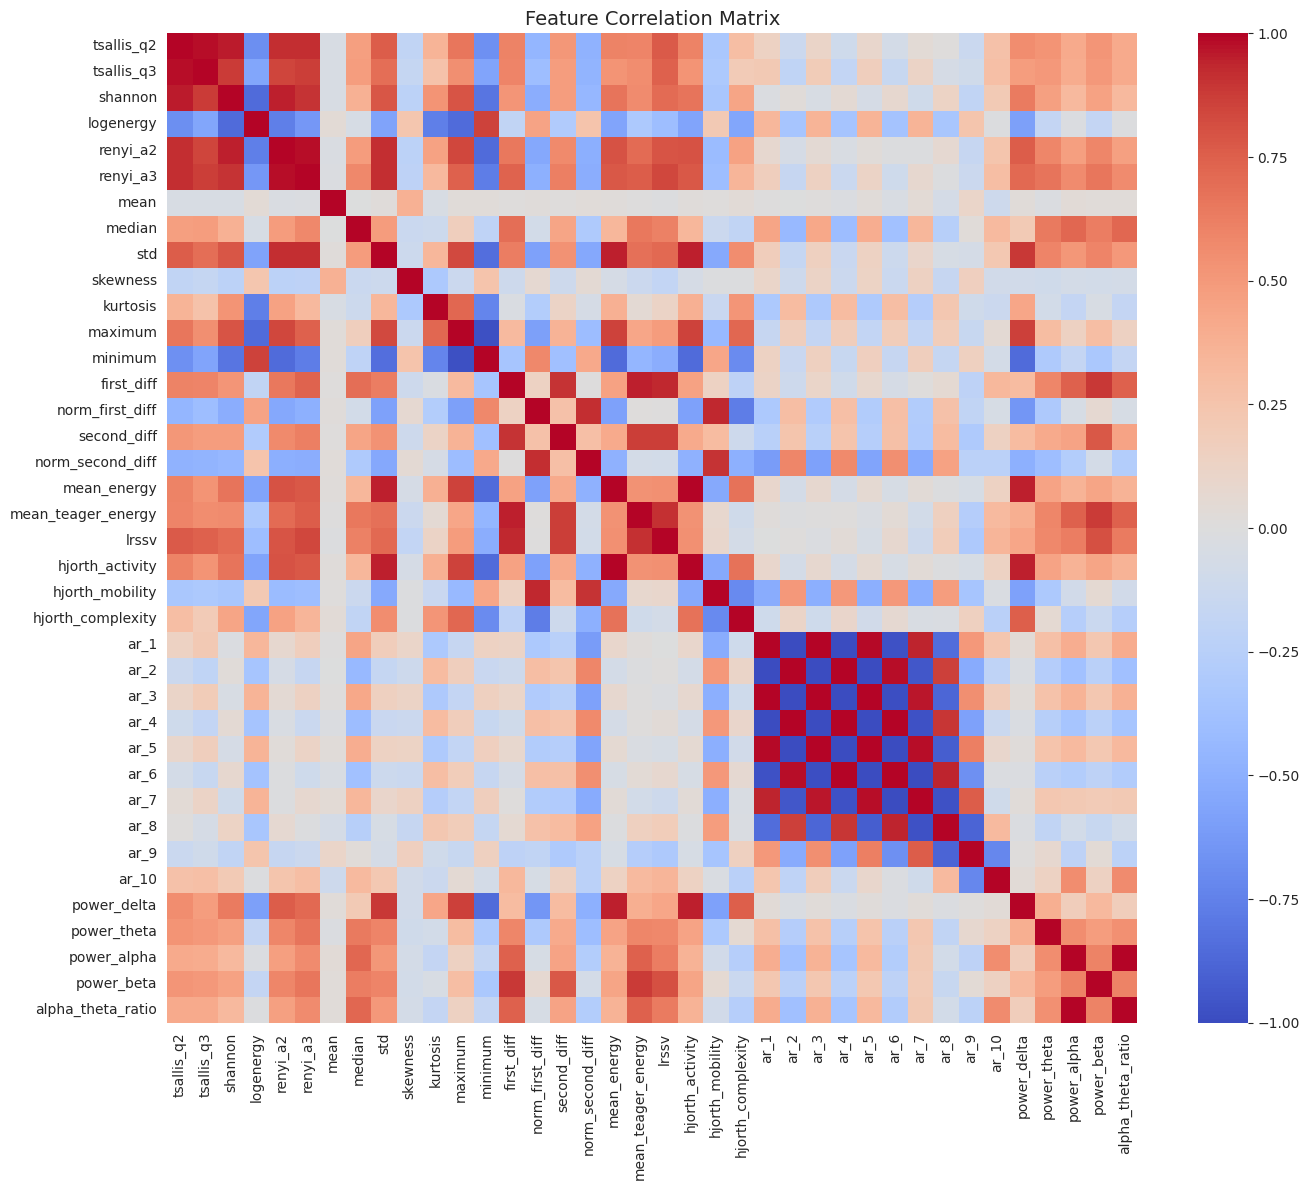

In [ ]:
# Calculate correlation between features

feature_means = data_clean[feature_cols]
data_corr = feature_means.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(data_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

<br>

**Two important observations:**

**1)** Frequency features, specifically those derived from the autoregressive model (ar_1, ar_2...), presented a very high correlation pattern among themselves, while at the same time correlating weakly with most other features. The ar_1 to ar_8 features are highly correlated because:

* They measure the same temporal dynamics of the EEG.

* They capture the persistent autocorrelation of the signal.

* They are mathematical functions of one another. Therefore, they have strong linear dependence.

A possible explanation for ar_9 and ar_10 being different is that they represent residual components and capture noise not explained by lower orders.

**2)** Entropy features are also strongly correlated among themselves. The **log energy** feature correlates negatively with all others. This occurs because log energy is mathematically distinct from the others, capturing complementary and opposite aspects of the signal distribution shape.

**Again, the feature selection step will be essential to eliminate redundancies such as those observed in the heatmap, retaining only the relevant information.**

<br>

<br>

---



### <font color=#4682b4>**Part 4 - Feature engineering**</font>

Based on previous work *(Colombo et al., 2023; Drążyk et al., 2024; Gordon et al., 2010; Jia et al., 2026)*, additional features to be extracted from EEG data have been identified, with promising potential for differentiating psychiatric disorders and, more specifically, psychosis.
<br><br>

**The new attributes can be extracted directly from the frequency features already present in the current dataset:**

* Spectral frequency ratios:

* Hemispheric asymmetry features (absolute frequency and ratios)

* Topographic gradients (ratio differences between frontal, central, temporal, parietal, and occipital regions).

<br>

In [ ]:
# Load the full feature dataset again
data = pd.DataFrame(
    pd.read_csv("/content/eeg_features.csv")
)

# Create the "dataset" column
data["dataset"] = np.where(data["subject_id"].isin(dataset_1), 1, 2)
print(data.shape)
print(data['dataset'].value_counts())

In [ ]:
# Name channels
canais = ['T8', 'F4', 'T7', 'C1', 'Pz', 'FC2',
          'C6', 'F3', 'P6', 'FC6', 'O1', 'C3',
          'F5', 'C5', 'CP3', 'FC1', 'PO4', 'AF4',
          'FC5', 'FT8', 'FT7', 'PO7', 'TP7', 'P8',
          'C2', 'F2', 'C4', 'PO3', 'P7', 'CP1',
          'F7', 'F6', 'P3', 'O2', 'F8', 'PO8',
          'Fz', 'CP4', 'P4', 'AF3', 'Cz', 'Fp1',
          'Fp2', 'P5', 'F1', 'TP8', 'AF7', 'CP2']

In [ ]:
# Features with new spectral frequency ratios

novas_razoes = [
    ('delta', 'beta'),
    ('delta', 'alpha'),
    ('delta', 'theta'),
    ('theta', 'beta'),
    ('theta', 'alpha'),
    ('theta', 'delta'),
    ('alpha', 'beta'),
    ('alpha', 'delta')
  ]

# Dictionary to store ratios
razoes_features = {}

# Calculate ratios for all channels
for canal in canais:
    for num, den in novas_razoes:
        col_num = f'power_{num}_{canal}'
        col_den = f'power_{den}_{canal}'

        if col_num in data.columns and col_den in data.columns:
            nome = f'{num}_{den}_ratio_{canal}'
            razoes_features[nome] = data[col_num] / data[col_den]

# Add to dataframe
razoes_df = pd.DataFrame(razoes_features, index=data.index)
data = pd.concat([data, razoes_df], axis=1)
print(f"{len(razoes_features)} spectral ratios created")
print(f"Expected: {len(novas_razoes)} ratios × {len(canais)} channels = {len(novas_razoes) * len(canais)}")

print(f"Total features: {data.shape[1]}")

In [ ]:
# Hemispheric asymmetry features (2 parts)

print(canais)

# Define channel pairs (odd = left hemisphere, even = right hemisphere)
pares_hemisfericos = [
    ('Fp1', 'Fp2'),
    ('AF3', 'AF4'),
    ('F1', 'F2'),
    ('F3', 'F4'),
    ('F5', 'F6'),
    ('F7', 'F8'),
    ('FC1', 'FC2'),
    ('FC5', 'FC6'),
    ('FT7', 'FT8'),
    ('C1', 'C2'),
    ('C3', 'C4'),
    ('C5', 'C6'),
    ('T7', 'T8'),
    ('TP7', 'TP8'),
    ('CP1', 'CP2'),
    ('CP3', 'CP4'),
    ('P3', 'P4'),
    ('P5', 'P6'),
    ('P7', 'P8'),
    ('PO3', 'PO4'),
    ('PO7', 'PO8'),
    ('O1', 'O2'),
]

print(f"{len(pares_hemisfericos)} pairs = {len(pares_hemisfericos) * 2} channels")

# Define bands and ratios
bandas = ['delta', 'theta', 'alpha', 'beta']

razoes = ['delta_beta_ratio', 'delta_alpha_ratio', 'delta_theta_ratio',
          'theta_beta_ratio', 'theta_alpha_ratio', 'theta_delta_ratio',
          'alpha_beta_ratio', 'alpha_theta_ratio', 'alpha_delta_ratio'
]

In [ ]:
# 1) Absolute FREQUENCY asymmetry features
assimetrias_abs = {}

# Loop to calculate asymmetry
for ch_esq, ch_dir in pares_hemisfericos:
    for banda in bandas:
        col_esq = f'power_{banda}_{ch_esq}'
        col_dir = f'power_{banda}_{ch_dir}'

        if col_esq in data.columns and col_dir in data.columns:
          esquerda = data[col_esq].values
          direita = data[col_dir].values

          # Calculate asymmetry
          assimetria = np.log(direita + 1) - np.log(esquerda + 1)

          # Name of the new feature
          nome_feature = f'assimetria_{banda}_{ch_esq}_{ch_dir}'
          assimetrias_abs[nome_feature] = assimetria

# Add all features to the dataframe
assimetrias_df = pd.DataFrame(assimetrias_abs, index=data.index)
data = pd.concat([data, assimetrias_df], axis=1)
print(f"{len(assimetrias_abs)} asymmetry features created")
print(f"Total features: {data.shape[1]}")

In [ ]:
# 2) FREQUENCY RATIO asymmetry features
assimetrias_razoes = {}

# Loop to calculate asymmetry for each ratio
for ch_esq, ch_dir in pares_hemisfericos:
    for razao in razoes:

        # Name of ratio columns for each channel
        col_esq = f'{razao}_{ch_esq}'
        col_dir = f'{razao}_{ch_dir}'

        # Check if columns exist
        if col_esq in data.columns and col_dir in data.columns:
            esquerda = data[col_esq].values
            direita = data[col_dir].values

            # Calculate ratio asymmetry:
            assimetria = np.log(direita + 1) - np.log(esquerda + 1)

            # Name of the new feature
            nome_feature = f'assimetria_{razao}_{ch_esq}_{ch_dir}'
            assimetrias_razoes[nome_feature] = assimetria

# Add all features to the dataframe
assimetrias_df = pd.DataFrame(assimetrias_razoes, index=data.index)
data = pd.concat([data, assimetrias_df], axis=1)
print(f"{len(assimetrias_razoes)} ratio asymmetries created")
print(f"Total features: {data.shape[1]}")

In [ ]:
# Topographic gradient features (regional)

regioes = {
    'frontal': ['Fp1', 'Fp2', 'AF3', 'AF4', 'AF7', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'Fz'],
    'central': ['FC1', 'FC2', 'FC5', 'FC6', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'Cz'],
    'temporal': ['FT7', 'FT8', 'T7', 'T8', 'TP7', 'TP8'],
    'parietal': ['CP1', 'CP2', 'CP3', 'CP4', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'Pz'],
    'occipital': ['PO3', 'PO4', 'PO7', 'PO8', 'O1', 'O2']
}

medias_regionais = {}

# Regional mean for each frequency ratio
for regiao, canais_regiao in regioes.items():

    for razao in razoes:

        # Column names for the region and ratio
        cols = [f'{razao}_{ch}' for ch in canais_regiao if f'{razao}_{ch}' in data.columns]

        # Calculate the mean (across columns/axis=1)
        media = data[cols].mean(axis=1)

        # Name of the new feature
        nome_feature = f'media_{regiao}_{razao}'
        medias_regionais[nome_feature] = media

# Add all regional means to the dataframe
medias_df = pd.DataFrame(medias_regionais, index=data.index)
data = pd.concat([data, medias_df], axis=1)
print(f"\nResult: {len(medias_regionais)} regional means created")
print(f"Total features: {data.shape[1]}")

In [ ]:
# Calculate topographic gradients from means

# Define region pairs to calculate gradient (difference)
gradientes = [
    ('frontal', 'occipital'),
    ('frontal', 'parietal'),
    ('frontal', 'central'),
    ('frontal', 'temporal'),
    ('central', 'occipital'),
    ('parietal', 'occipital'),
    ('temporal', 'occipital'),
]

features_gradientes = {}

# Calculate gradients
for regiao1, regiao2 in gradientes:
    for razao in razoes:
        col1 = f'media_{regiao1}_{razao}'
        col2 = f'media_{regiao2}_{razao}'

        if col1 in data.columns and col2 in data.columns:
            gradiente = data[col1] - data[col2]
            nome = f'gradiente_{regiao1}_{regiao2}_{razao}'
            features_gradientes[nome] = gradiente

# Add gradients to DataFrame
gradientes_df = pd.DataFrame(features_gradientes, index=data.index)
data = pd.concat([data, gradientes_df], axis=1)
print(f"\nResult: {len(features_gradientes)} regional gradients created")
print(f"Total features: {data.shape[1]}")

In [ ]:
# Remove regional mean features and keep only gradients
features_redundantes = medias_df.columns.tolist()

data = data.drop(features_redundantes, axis=1)
print(f"Columns removed: {len(features_redundantes)}")
print(f"Total features: {data.shape[1]}")

Columns removed: 45
Total features: 2561


<br>

**Many new attributes were created!**

Since most attributes are calculated per channel (48), in addition to some of the new attributes calculated per brain region, our feature engineering resulted in a feature space of **2557 features (see feature importance step below)**.

<br>

<br>

---



### <font color=#4682b4>**Part 5 - Model Training**</font>

Four classification models will be trained:
  * **Dummy Classifier** (naive baseline)
  * **Logistic Regression (LogReg)**
  * **K-Nearest Neighbors (KNN)**
  * **Random Forest Classifier (RF)**
<br>

**Performance evaluation:**

* For each model, except for the baseline, hyperparameters will be optimized via *GridSearch* aiming to maximize their discriminative power, a characteristic best expressed by the **AUC (*Area Under the Curve*)** metric.


* Cross-validation will be performed with 5 folds, ensuring that each of the 143 observations is used for testing exactly once, maximizing data usage. **The use of cross-validation with a fixed seed also allows for a fair comparison between models and the subsequent evaluation of internal instability within each fold.**


* Next, the threshold that best balances **sensitivity and specificity** will be extracted via *Youden's Index*.


* Finally, the 4 models will be visually compared through ROC curves and boxplots.

#### **Preparation**

Preparation for model training consists of 5 steps:

**1)** Define feature variables (X) and target variable (y).

**2)** Instantiate a pipeline of **(a)** power transformation (Yeo-Johnson) to reduce skewness and maximize data normality; and **(b)** standardization (StandardScaler) to uniformize variances.

**3)** Instantiate a fixed KFold (StratifiedKFold with shuffle) to be used across all models, allowing for better comparability.

**4)** Inspect feature importance.

**5)** PCA for batch effect diagnosis - systematic differences between dataset 1 and dataset 2.

<br>

In [ ]:
# Define features

feature_cols = [c for c in data.columns
                if c not in ('subject_id', 'group', 'label', 'dataset')]

X = data[feature_cols].values

# Define target variable
y = data["label"].values

print(f"Feature array shape (X): {X.shape}")
print(f"Target variable shape (y): {y.shape}")

Feature array shape (X): (143, 2557)
Target variable shape (y): (143,)


In [ ]:
# Instantiate a processing Pipeline
processor = Pipeline([
    ("yeo_johnson", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

In [ ]:
# Instantiate a fixed KFold to be used across all models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

<br>

#### **Feature importance (exploratory)**

Next, we will test some preliminary feature selection scenarios. As mentioned before, this selection will be performed using a **Logistic Regression model with L1 penalization (lasso)**.

Then, we will analyze the linear importance of the selected features.

<br>

In [ ]:
# Check feature sparsity for different penalization levels (C)
# Processing time: ~20 seconds

modelos_selecionados = []

X_processed = processor.fit_transform(X)

# Check sparsity for different penalization levels (parameters C and l1_ratio)
for C in [0.05, 0.1, 0.3, 0.5, 0.7, 1, 5, 10, 50, 100]:
    lr = LogisticRegression(penalty='l1',
                            solver='liblinear',
                            C=C,
                            class_weight='balanced',
                            random_state=42,
                            max_iter=1000)
    lr.fit(X_processed, y)

    coefs = lr.coef_[0]
    n_selected = (np.abs(lr.coef_[0]) > 1e-6).sum()
    print(f"C={C}: {n_selected} features selected out of {X_processed.shape[1]}")

    if 20 <= n_selected <= 100:
          modelos_selecionados.append({
          'C': C,
          'n_selected': n_selected,
          'model': lr,
          'coefs': coefs
      })

C=0.05: 2 features selected out of 2557
C=0.1: 21 features selected out of 2557
C=0.3: 63 features selected out of 2557
C=0.5: 78 features selected out of 2557
C=0.7: 77 features selected out of 2557
C=1: 90 features selected out of 2557
C=5: 104 features selected out of 2557
C=10: 152 features selected out of 2557
C=50: 260 features selected out of 2557
C=100: 361 features selected out of 2557


<br>

L1 penalization finds an adequate number of features for C values in the range [0.1, 0.3, 0.5], considering the small size of our sample (n=143).

**These C values will be implemented in the GridSearch of the models**, in order to decide the best number of features for each model, within this range.

<br>

In [ ]:
# Visualize sparsity and most important features for C=0.5

modelo = next((m for m in modelos_selecionados if m['C'] == 0.5), None)

# Get indices of selected features
idx = np.where(np.abs(modelo['coefs']) > 1e-6)[0]

# Get names and coefficients
nomes = [feature_cols[i] for i in idx]
coefs = modelo['coefs'][idx]

# Create dataframe and sort by ABSOLUTE VALUE (importance)
df = pd.DataFrame({
    'feature': nomes,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
  })
df = df.sort_values('abs_coef', ascending=False)

# Display
print(f"Model C=0.5: {len(df)} selected features\n")
print(df.to_string(index=False))
print("\n")

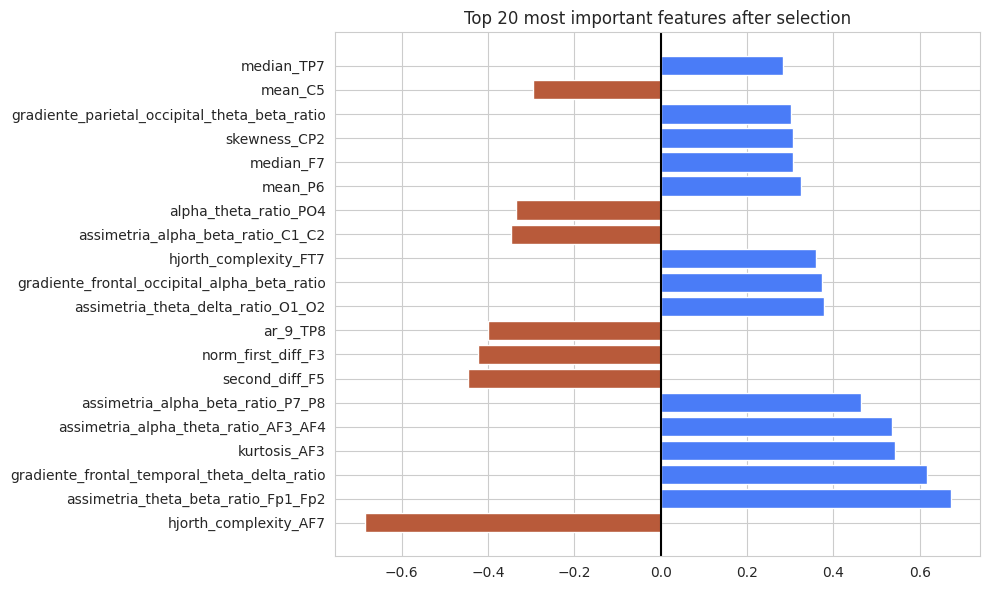

In [ ]:
# Plot top 20
top = df.head(20)
plt.figure(figsize=(10, 6))
colors = ['#4A7CF7' if c > 0 else '#B85A3A' for c in top['coef']]
plt.barh(top['feature'], top['coef'], color=colors)
plt.axvline(0, color='black')
plt.title(f'Top 20 most important features after selection')
plt.tight_layout()
plt.show()

<br>

#### **Batch effect diagnosis**

Batch effects should always be investigated when dealing with datasets coming from different EEG montages or collected at different times.

To prevent machine learning models from learning systematic differences between datasets rather than real differences between classes, **we will inspect feature clustering through PCA.**

<br>

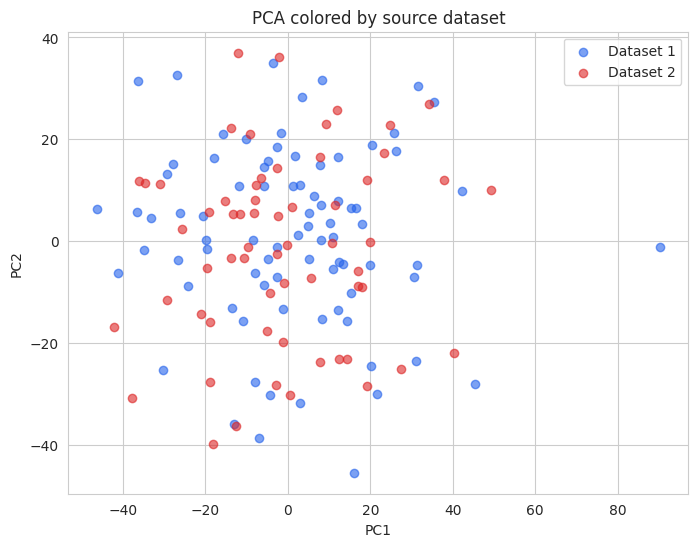

In [ ]:
# Perform PCA for batch effect diagnosis
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for batch, color in [(1, '#2563eb'), (2, '#dc2626')]:
    idx = data['dataset'] == batch
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=f'Dataset {batch}', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA colored by source dataset')
plt.legend()
plt.show()

<br>

**The PCA diagnosis looks great.** It indicates that the datasets are well mixed across components, suggesting that batch effect is negligible in this data (no cluster formation).

Therefore, it will not be necessary to implement any form of harmonization between datasets in the Pipeline.

<br>

<br>

#### **Baseline model**

As a baseline for comparison with the classifier models, a **naive classifier with DummyClassifier** will be implemented.

This classifier follows a simple rule and is not capable of learning or generalization. It simply classifies all data with the most frequent class - in this case, psychosis (label 1).

<br>

In [ ]:
# Instantiate the baseline
dummy_baseline = DummyClassifier(strategy="most_frequent")

# Probabilities
y_proba_dummy = cross_val_predict(
    dummy_baseline,
    X,
    y,
    cv=cv,
    method='predict_proba'
)[:, 1]

# Classes
y_pred_dummy = (y_proba_dummy >= 0.5).astype(int)

# Extract AUC
print(f"\nMean AUC across folds:   {roc_auc_score(y, y_proba_dummy):.3f}\n")


Mean AUC across folds:   0.500



<br>

#### **LogReg Model**

A **Logistic Regression** model will be trained with cross-validation and hyperparameter optimization via *GridSearch*.

**Feature selection:** A separate model, also logistic regression, but with **optimized L1 penalization** will be used to select attributes and reduce model dimensionality. This can be done via *SelectFromModel*.

<br>

In [ ]:
# Train a classifier with Logistic Regression
# With feature selection via L1 penalization

# Feature selector
selector = SelectFromModel(
    LogisticRegression(
        class_weight='balanced',
        penalty="l1",
        solver="liblinear",
        random_state=42,
        max_iter=5000
    ),
    threshold=1e-6
)

# Instantiate the classifier model
log_reg = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)

# Instantiate the Pipeline
full_pipeline = Pipeline([
    ("processor", processor),
    ("selector", selector),
    ("model", log_reg)
])

# Define the dictionary for gridsearch
grid_dict = [
    {'selector__estimator__C': [0.1, 0.3],
     'model__penalty': ['l1'],
     'model__solver': ['liblinear'],
     'model__C': [0.1, 0.5, 1]},

    {
     'selector__estimator__C': [0.1, 0.3],
     'model__penalty': ['l2'],
     'model__solver': ['liblinear'],
     'model__C': [0.1, 0.5, 1]}
]

# Instantiate a gridsearch with CV
gridsearch_logreg = GridSearchCV(
                          estimator = full_pipeline,
                          param_grid = grid_dict,
                          scoring = 'roc_auc',
                          cv = cv,
                          n_jobs = -1,
                          verbose = 1
                          )

In [ ]:
# Run the model with gridsearch
# Processing time: ~6 minutes

gridsearch_logreg.fit(X, y)

# Extract results
print("Results:")
print("\nBest hyperparameters:")
print(gridsearch_logreg.best_params_)

# Best model possible with the given grid
print("\nBest model:")
print(gridsearch_logreg.best_estimator_)

# Features selected by the best estimator
best_selector_step = gridsearch_logreg.best_estimator_.named_steps["selector"]

n_features_selected = best_selector_step.get_support().sum()
print(f"Features selected: {n_features_selected}")

# Extract the mean AUC across 5 folds
print("\nMean AUC across folds:")
print(gridsearch_logreg.best_score_)

<br>

#### **KNN Model**

A **K-Nearest Neighbors (KNN)** classifier will be trained with hyperparameter optimization and cross-validation via *GridSearch*.

**Feature selection:** A Logistic Regression with **optimized L1 penalization** will be employed, extracting any non-zero coefficient (greater than 1e-6). **Feature selection must be embedded within the general Pipeline to avoid data leakage.**

<br>

In [ ]:
# Train a K-Nearest Neighbors (KNN) classifier
# With feature selection via logistic regression with L1 penalization

selector = SelectFromModel(
    LogisticRegression(
        class_weight='balanced',
        penalty="l1",
        solver="liblinear",
        random_state=42,
        max_iter=5000),
    threshold=1e-6
)

# Instantiate the model
model_knn = KNeighborsClassifier()

# Instantiate the full pipeline
full_pipeline = Pipeline([
    ("processor", processor),
    ("selector", selector),
    ("model", model_knn)
])

# Define the dictionary for gridsearch
grid_dict = {
    'selector__estimator__C': [0.1, 0.3, 0.5],
    'model__n_neighbors': [5, 11, 15],
    'model__weights': ['distance'],
    'model__metric': ['euclidean', 'cosine'],
}

# Instantiate a gridsearch with CV
gridsearch_knn = GridSearchCV(
                          estimator = full_pipeline,
                          param_grid = grid_dict,
                          scoring = 'roc_auc',
                          cv = cv,
                          n_jobs = -1,
                          verbose = 1
)

In [ ]:
# Run the model with gridsearch
# Processing time: ~8 minutes

gridsearch_knn.fit(X, y)

# Extract results
print("Results:")
print("\nBest hyperparameters:")
print(gridsearch_knn.best_params_)

# Best model possible with the given grid
print("\nBest model:")
print(gridsearch_knn.best_estimator_)

# Features selected by the best estimator
best_selector_step = gridsearch_knn.best_estimator_.named_steps["selector"]

n_features_selected = best_selector_step.get_support().sum()
print(f"Features selected: {n_features_selected}")

# Extract the mean AUC across 5 folds
print("\nMean AUC across folds:")
print(gridsearch_knn.best_score_)

<br>

#### **Random Forest Model**

A **Random Forest (RF)** classifier will be trained with hyperparameter optimization and cross-validation via *GridSearch*.

**Feature selection:** A Logistic Regression with **optimized L1 penalization** will be employed, extracting any non-zero coefficient (greater than 1e-6). **To avoid data leakage, feature selection must be embedded within the general Pipeline.**

<br>

In [ ]:
# Train a Random Forest classifier
# With feature selection via L1 penalization

selector = SelectFromModel(
    LogisticRegression(
        class_weight='balanced',
        penalty="l1",
        solver="liblinear",
        random_state=42,
        max_iter=5000),
    threshold=1e-6
)

# Instantiate the model
model_rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state = 42
)

# Instantiate the pipeline
full_pipeline = Pipeline([
    ("processor", processor),
    ("selector", selector),
    ("model", model_rf)
])

# Define the dictionary for gridsearch
grid_dict = {
    'selector__estimator__C': [0.1, 0.3],
    'model__max_depth': [2, 4],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt']
}

# Instantiate a gridsearch with CV
gridsearch_rf = GridSearchCV(
                          estimator = full_pipeline,
                          param_grid = grid_dict,
                          scoring = 'roc_auc',
                          cv = cv,
                          n_jobs = -1,
                          verbose = 1
)

In [ ]:
# Run the model with gridsearch
# Estimated processing time: ~7 minutes

gridsearch_rf.fit(X, y)

# Extract results
print("Results:")
print("\nBest hyperparameters:")
print(gridsearch_rf.best_params_)

# Best model possible with the given grid
print("\nBest model:")
print(gridsearch_rf.best_estimator_)

# Features selected by the best estimator
best_selector_step = gridsearch_rf.best_estimator_.named_steps["selector"]

n_features_selected = best_selector_step.get_support().sum()
print(f"Features selected: {n_features_selected}")

# Extract the mean AUC across 5 folds
print("\nMean AUC across folds:")
print(gridsearch_rf.best_score_)

<br>



---


### <font color=#4682b4>**Part 6 - Evaluation**</font>

Now that we have trained the models with optimized hyperparameters, let's compare them across all metrics, **considering the performance of each fold separately and the mean across folds.**
<br>

**1)** We will visualize the discriminative power of the models through ROC curves.

**2)** We will visualize the most important metrics through boxplots.

**3)** We will have a brief discussion about the results.

<br>

In [ ]:
# Evaluation of models by fold
# Estimated processing time: ~4 minutes

# Dictionary with the three already fitted gridsearches
grids = {
    'Logistic Regression': gridsearch_logreg,
    'K-Nearest Neighbors': gridsearch_knn,
    'Random Forest': gridsearch_rf,
}

# Empty dictionaries for metrics, thresholds and predicted probabilities
all_fold_metrics = {}
best_thresholds = {}
all_y_proba = {}

# Loop for all models
for model_name, gridsearch in grids.items():

    print(f"\n=> Model: {model_name}")
    best_estimator = gridsearch.best_estimator_

    # Predictions to find the optimal threshold (Youden)
    y_proba = cross_val_predict(
        best_estimator, X, y, cv=cv, method='predict_proba'
    )[:, 1]

    all_y_proba[model_name] = y_proba

    fpr, tpr, thresholds_roc = roc_curve(y, y_proba)
    youden_index = tpr - fpr
    best_threshold = thresholds_roc[np.argmax(youden_index)]
    best_thresholds[model_name] = best_threshold

    print(f"\nBalanced threshold (Youden): {best_threshold:.3f}")

    # Loop through folds calculating metrics with the model's threshold
    fold_metrics = []

    for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        fold_model = clone(best_estimator)
        fold_model.fit(X_train, y_train)

        y_proba_fold = fold_model.predict_proba(X_test)[:, 1]
        y_pred_fold = (y_proba_fold >= best_threshold).astype(int)

        fold_metrics.append({
            'fold': fold_i,
            'AUC': roc_auc_score(y_test, y_proba_fold),
            'Accuracy': accuracy_score(y_test, y_pred_fold),
            'Sensitivity': recall_score(y_test, y_pred_fold, pos_label=1),
            'Specificity': recall_score(y_test, y_pred_fold, pos_label=0),
            'Precision': precision_score(y_test, y_pred_fold, zero_division=0),
            'F1': f1_score(y_test, y_pred_fold, zero_division=0),
        })

    # Save metrics in a Dataframe
    fold_metrics_df = pd.DataFrame(fold_metrics)
    all_fold_metrics[model_name] = fold_metrics_df

    print("\nMetrics by fold:")
    print(fold_metrics_df)

    print("\nMean across folds:")
    print(fold_metrics_df.drop(["fold"], axis=1).mean(numeric_only=True))

    print("\nStandard deviation across folds:")
    print(fold_metrics_df.drop(["fold"], axis=1).std(numeric_only=True))
    print("\n")


=> Model: Logistic Regression

Balanced threshold (Youden): 0.433

Metrics by fold:
   fold       AUC  Accuracy  Sensitivity  Specificity  Precision        F1
0     1  0.617647  0.620690     0.823529     0.333333   0.636364  0.717949
1     2  0.538462  0.655172     0.875000     0.384615   0.636364  0.736842
2     3  0.725962  0.724138     0.937500     0.461538   0.681818  0.789474
3     4  0.718750  0.678571     0.812500     0.500000   0.684211  0.742857
4     5  0.437500  0.535714     0.562500     0.500000   0.600000  0.580645

Mean across folds:
AUC            0.607664
Accuracy       0.642857
Sensitivity    0.802206
Specificity    0.435897
Precision      0.647751
F1             0.713553
dtype: float64

Standard deviation across folds:
AUC            0.122657
Accuracy       0.070719
Sensitivity    0.142849
Specificity    0.074204
Precision      0.035459
F1             0.078818
dtype: float64



=> Model: K-Nearest Neighbors

Balanced threshold (Youden): 0.544

Metrics by fold:
   fol

In [ ]:
# Final comparative summary (mean of each metric per model)
summary_df = pd.DataFrame({
    name: df.mean(numeric_only=True)
    for name, df in all_fold_metrics.items()}
    ).T.drop(columns='fold')

# Compare with the naive classifier (dummy) metrics
dummy_metrics = {
    'AUC': roc_auc_score(y, y_proba_dummy),
    'Accuracy': accuracy_score(y, y_pred_dummy),
    'Sensitivity': recall_score(y, y_pred_dummy, pos_label=1),
    'Specificity': recall_score(y, y_pred_dummy, pos_label=0),
    'Precision': precision_score(y, y_pred_dummy, zero_division=0),
    'F1': f1_score(y, y_pred_dummy, zero_division=0)
}

# Add dummy metrics to the comparative dataframe
summary_df.loc['Dummy'] = dummy_metrics

print("Comparative summary (means across folds):\n")
print(summary_df.T)

Comparative summary (means across folds):

             Logistic Regression  K-Nearest Neighbors  Random Forest     Dummy
AUC                     0.607664             0.632438       0.645904  0.500000
Accuracy                0.642857             0.664532       0.671921  0.566434
Sensitivity             0.802206             0.702941       0.779412  1.000000
Specificity             0.435897             0.614103       0.535897  0.000000
Precision               0.647751             0.722010       0.688889  0.566434
F1                      0.713553             0.703133       0.728067  0.723214


<br>

#### **ROC Curves**

<br>

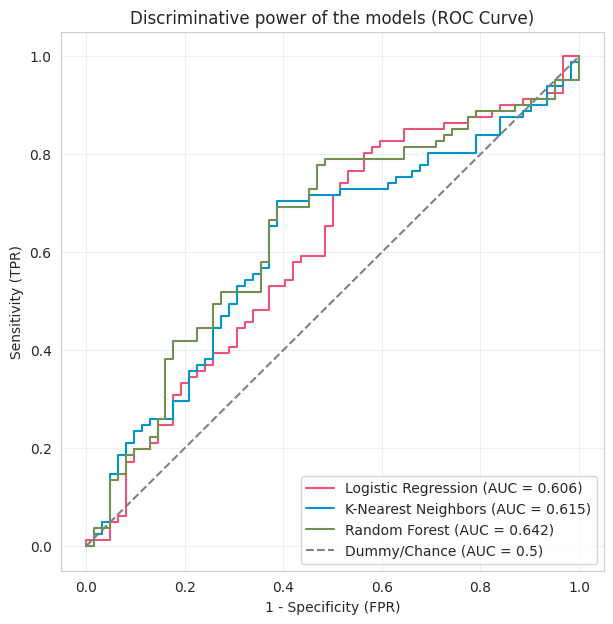

In [ ]:
# Visualize model discriminative power with ROC curves

# Define palette
roc_colors = {
    'Logistic Regression': '#EC5578',
    'K-Nearest Neighbors': '#0096C7',
    'Random Forest': '#738f52',
}

# Plot
plt.figure(figsize=(7, 7))

# Loop for all models
for model_name, y_proba_oof in all_y_proba.items():
    fpr, tpr, _ = roc_curve(y, y_proba_oof)
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        color=roc_colors.get(model_name, None),
        linewidth=1.5,
        label=f'{model_name} (AUC = {roc_auc:.3f})'
    )

# Dummy/chance line and additional settings
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Dummy/Chance (AUC = 0.5)')
plt.xlabel('1 - Specificity (FPR)')
plt.ylabel('Sensitivity (TPR)')
plt.title('Discriminative power of the models (ROC Curve)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

<br>

#### **Comparative boxplots**

<br>

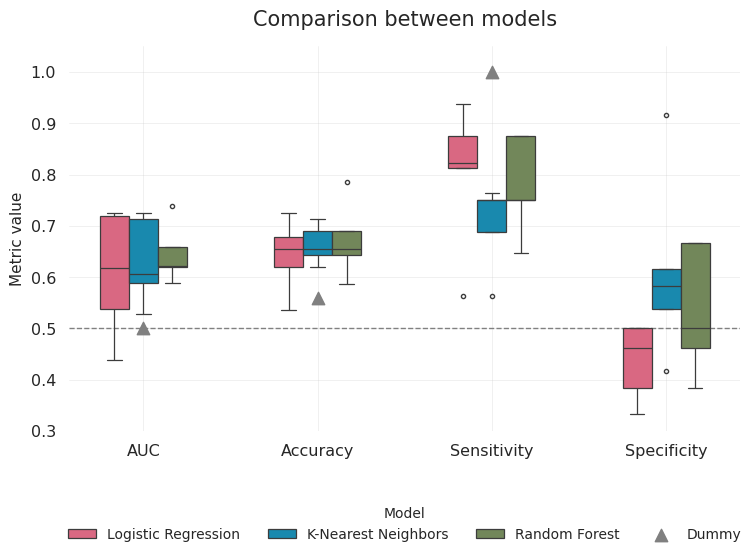

In [ ]:
# Comparative boxplot (AUC, Accuracy, Sensitivity)
combined_df = pd.concat(all_fold_metrics, names=['model']).reset_index(level=0)

# Select metrics from the dataframe
metrics_of_interest = ['AUC', 'Accuracy', 'Sensitivity', 'Specificity']
plot_df = combined_df.melt(
    id_vars='model',
    value_vars=metrics_of_interest,
    var_name='metric',
    value_name='value'
)

# Plot
sns.set_theme(style='whitegrid', font_scale=1.05)
sns.set_palette("muted")

fig, ax = plt.subplots(figsize=(8, 6))

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)

# Comparative boxplot (3 models)
sns.boxplot(
    data=plot_df,
    x='metric',
    y='value',
    hue='model',
    palette = roc_colors,
    linewidth=0.9,
    width=0.5,
    fliersize=3,
    ax=ax
)

# Dummy metrics (triangles)
ax.scatter(x=0, y=0.50, s=80, marker="^", color='gray', zorder=1, label="Dummy")
ax.scatter(x=1, y=0.56, s=80, marker="^", color='gray', zorder=1)
ax.scatter(x=2, y=1, s=80, marker="^", color='gray', zorder=1)

# Additional settings
ax.set_xlabel('')
ax.set_ylabel('Metric value', fontsize=11)
ax.set_title('Comparison between models', fontsize=15, weight='medium', pad=15)
ax.set_ylim(0.30, 1.05)
ax.grid(axis='y', alpha=0.4, linewidth=0.5)
ax.grid(axis='x', alpha=0.4, linewidth=0.5)

sns.despine(left=True, bottom=True)

ax.legend(
    title='Model',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.32),
    ncol=4,
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

<br>

#### **LogReg Summary**

* The **Logistic Regression** model showed weak discriminative power, but better than chance and the naive classifier **(AUC=0.607)**. The AUC exceeded the .70 range in 2 folds, varying considerably across the 5 folds.

* The optimized feature selection with L1 penalization determined a penalty of **C=0.1** as the best option for AUC maximization, resulting in the extraction of **only 21 features out of the 2557 total feature space**.

* With the optimal threshold according to Youden's Index, the classifier drastically prioritizes the detection of true positives (psychosis) over the detection of true negatives (control). **Despite its good sensitivity, its ability to classify healthy subjects was below chance.**
<br>

Overall, the classifier has little diagnostic utility on its own.

<br>

<br>

#### **KNN Summary**

* The **K-Nearest Neighbors** model also showed modest discriminative power, but slightly superior to the Logistic Regression model **(AUC=0.632)**, on average.

* The optimized feature selection with L1 penalization determined a penalty of **C=0.5** as the best option for AUC maximization, resulting in the extraction of **78 features out of the 2557 total feature space**.

* With the optimal threshold according to Youden's Index, the classifier prioritizes the detection of true positives (psychosis) over the detection of true negatives (control), but in a **more balanced way than the Logistic Regression, with specificity above chance in all folds, and with more stable values.** The KNN classifier was the most balanced model among the three.

* All KNN metrics were above chance in all folds, an interesting sign of robustness despite the weak performance.
<br>

Overall, it is a modest classifier with slightly superior and more stable performance than the Logistic Regression, but also with little diagnostic utility on its own.

<br>

<br>

#### **Random Forest Summary**

* The **Random Forest** classification model performed close to the other models, with modest discriminative power, slightly outperforming the Logistic Regression and KNN models with an **AUC≈0.650**, on average.

* The optimized feature selection with L1 penalization determined a penalty of **C=0.3** as the best option for AUC maximization, resulting in the extraction of **63 features out of the 2557 total feature space**.

* With the optimal threshold according to Youden's Index, the classifier also prioritizes much more the detection of true positives (psychosis) over the detection of true negatives (control), similar to the Logistic Regression. Although it presented mean specificity close to chance, **its ability to identify true negatives was superior to the Logistic Regression model in most folds.** There was large performance oscillation across folds in this case!
<br>

It is a modest classifier with slightly superior performance to Logistic Regression and KNN, but like the other models, it has little diagnostic utility on its own.

In the future, training with larger samples should be implemented to compare the performance between these models.

<br>

<br>

#### **Feature importance**

Feature selection revealed attributes with **linear contribution** to the predicted probability of the positive class (psychosis).

Among the most prominent features were statistical features, hemispheric asymmetry, and topographic gradient features:

* Hjorth complexity
* Theta/beta asymmetry
* Theta/delta asymmetry
* Alpha/theta asymmetry
* Alpha/beta asymmetry
* Frontal-temporal theta/delta gradient
* Frontal-occipital alpha/beta gradient
* Kurtosis
* First difference
* Second difference

<br>

<br>



---


# **Conclusion**

The project aimed to develop machine learning models for **classification of first-episode psychosis (FEP)** using electroencephalogram (EEG) signals, assisting in the early diagnosis of this condition. Additionally, it sought to identify attributes with the greatest linear contribution to the positive class (FEP).

**Public data from 143 individuals** (81 FEP, 62 controls) were used. The signals were preprocessed and underwent feature engineering. From this, three classification models were trained and optimized with cross-validation: **Logistic Regression, K-Nearest Neighbors, and Random Forest**. These were compared with a naive classifier (baseline), using AUC as the primary metric.
<br><br>

* The **statistical attributes** extracted from preprocessed EEG data and the **composite attributes extracted during feature engineering** demonstrated linear contribution to FEP prediction. **This corroborates previous studies regarding potential neurophysiological biomarkers of psychosis.**

* However, the machine learning models tested showed low discriminative power for FEP classification when trained with EEG attributes. **On one hand, the Random Forest classifier performed better, on average, than the Logistic Regression and KNN models. On the other hand, the KNN model was the one with the best balance between sensitivity and specificity, albeit with modest performance.**

* The models presented reasonable sensitivity but inadequate specificity. That is, the sensitivity/specificity trade-off of the models was not satisfactory for real clinical applications, as all three present a **high risk of false positives**.

* Furthermore, this study had a limited dataset size (n=143), which likely impaired the ability of the classifier models to identify real patterns and differentiate FEP subjects from healthy subjects (*underfitting*). **The limited sample also generated some instability in model performance when evaluated through cross-validation.**

* The incorporation of "phenotypic" variables, such as demographic data, behavioral scales, cognitive tests, and clinical observation, should be tested in classification models, where EEG data could function as **complementary attributes to enhance the discriminative power of these models**. To implement this type of clinical variable, special attention must be paid to the problem of diagnostic circularity.

* Finally, other model families could be implemented with more granular hyperparameter optimization and larger samples. This is the most direct path toward developing robust classifiers with EEG data.

<br>



---


# **References**

Colombo, M. A., Comanducci, A., Casarotto, S., Derchi, C. C., Annen, J., Viganò, A., & Rosanova, M. (2023). Beyond alpha power: EEG spatial and spectral gradients robustly stratify disorders of consciousness. Cerebral cortex, 33(11), 7193-7210.
<br>

Donoghue, T., Dominguez, J., & Voytek, B. (2020). Electrophysiological Frequency Band Ratio Measures Conflate Periodic and Aperiodic Neural Activity. eNeuro, 7(6), ENEURO.0192-20.2020.
<br>

Drążyk, D., Przewrocki, K., Górska-Klimowska, U. et al. (2024). Distinct Spectral Profiles of Awake Resting EEG in Disorders of Consciousness: The Role of Frequency and Topography of Oscillations. Brain Topogr 37, 138–151.
<br>

Gengeç Benli, Ş. (2023). Classification of First-Episode Psychosis with EEG Signals: ciSSA and Machine Learning Approach. Biomedicines, 11(12), 3223.
<br>

Gordon, E., Palmer, D. M., & Cooper, N. (2010). EEG alpha asymmetry in schizophrenia, depression, PTSD, panic disorder, ADHD and conduct disorder. Clinical EEG and neuroscience, 41(4), 178-183.
<br>

Gouvea, E. S., Noto, C., Bonadia, B., Senço, N. M. de, Gadelha, A., Bressan, R. A., & Cordeiro, Q. (2014). First-episode psychosis: emergency care. Debates Em Psiquiatria, 4(6), 16–22.
<br>

Howells, F. M., Temmingh, H. S., Hsieh, J. H., van Dijen, A. V., Baldwin, D. S., & Stein, D. J. (2018). Electroencephalographic delta/alpha frequency activity differentiates psychotic disorders: a study of schizophrenia, bipolar disorder and methamphetamine-induced psychotic disorder. Translational psychiatry, 8(1), 75.
<br>

Jia, S., Liu, W., Zhao, Q., Yun, S., Xin, X., Liu, C., & Wang, X. (2026). Hemispheric asymmetry in depressive symptoms is associated with sex-divergent functional brain connectivity patterns. Iscience, 29(4).
<br>

Naeim, M., & Narimani, M. (2026). EEG-based biomarkers for psychosis: Comparative performance of support vector machines and deep neural networks. Biological Psychology, 109232.
<br>

Perrottelli A, Giordano GM, Brando F, Giuliani L and Mucci A (2021) EEG-Based Measures in At-Risk Mental State and Early Stages of Schizophrenia: A Systematic Review. Front. Psychiatry 12:653642.
<br>

Redwan, S.M., Uddin, M.P., Ulhaq, A. et al. (2024). Power spectral density-based resting-state EEG classification of first-episode psychosis. Sci Rep 14, 15154.
<br><br>

*DeepSeek V4 and Claude Sonnet 5 language models were used for optimization, formatting, and code review in this project.*